# Config

In [6]:
# ==============================================================================
# CELL 1: MASTER CONFIGURATION [CASE: BESTEST_AIR]
#
# Research Task: Residual DRL with Transfer Learning (Symmetrical Observation)
#
# Core Strategy:
#   1. Residual Action: DRL outputs Delta T relative to Baseline (+/- 6.0K).
#   2. Normalization: Rewards divided by N_ZONES (1.0).
#   3. Occupancy: Binary Masking (Present/Absent).
#   4. Observation: 4-Past (Inertia) + 4-Future (Forecast) + Time Encoding.
# ==============================================================================
import os
import numpy as np

class Config:
    """
    Configuration for 'bestest_air' case.
    Target: Typical Cool (Part-load optimization).
    """
    # --- 1. Case Identity & Connection ---
    CASE_NAME = 'bestest_air'
    # BOPTEST_URL = 'http://host.docker.internal:80' # Docker Desktop (Win/Mac)
    BOPTEST_URL = 'http://127.0.0.1:80'              # Local/Linux
    
    # --- 2. Time & Scenario Settings ---
    # Scenario: Typical Cool (Part-load)
    # Start Day: 244 (Sep 1st approx)
    START_DAY = 196 
    
    # Durations (in Days)
    RBC_COLLECT_DAYS = 14  # 7 Days Train-set equivalent + 7 Days Validation

    # Simulation Steps
    CONTROL_PERIOD = 900  # 15 mins (Action Frequency)
    SAMPLING_PERIOD = 900 # 15 mins (Data Recording Frequency)
    
    # --- 3. Physical Normalization (CRITICAL FOR TRANSFER LEARNING) ---
    # Zone Count: Used to normalize total energy/penalty 
    N_ZONES = 1.0 
    
    # Max System Power (Watts) - Used for normalizing power history (0.0 - 1.0)
    # bestest_air ~ 5000W peak
    MAX_SYSTEM_POWER = 1500.0
    
    # Occupancy Type: 
    # True = Binary (Someone is there? 1 : 0). 
    # We use True to unify 2-person vs 200-person cases.
    USE_BINARY_OCCUPANCY_MASK = True 

    # --- 4. Action Space (Residual Control) ---
    # DRL Action: [-1, 1] -> Mapped to +/- SCALE
    RESIDUAL_ACTION_SCALE = 5.0 # Delta Range: +/- 4.0 K
    
    # Baseline Reference (Cooling)
    BASE_COOLING_SETPOINT = 25.0
    
    # HARD CONSTRAINT: Heating is LOCKED (Safety)
    FIXED_HEATING_SETPOINT = 15.0 
    
    # Action Names (BOPTEST Inputs)
    ACTION_U_NAMES = ['con_oveTSetCoo_u', 'con_oveTSetHea_u']
    
    # --- 5. Observation Space (4-Past, 4-Future Symmetrical) ---
    # Structured for LLM/Transfer Learning to capture inertia and planning
    OBSERVATION_COLUMNS = [
        # --- 5.1 Time Encoding (Cyclic) ---
        'obs_sin_time', 
        'obs_cos_time',
        
        # --- 5.2 Zone Thermal State (Inertia: t0 + t-1...t-4) ---
        'obs_zon_reaTRooAir_y',         # Current
        'obs_zon_reaTRooAir_y_past_1', 
        'obs_zon_reaTRooAir_y_past_2', 
        'obs_zon_reaTRooAir_y_past_3', 
        'obs_zon_reaTRooAir_y_past_4',
        
        # --- 5.3 System State & Comfort ---
        'obs_pp_pmv_y',                 # Current PMV
        
        # Past Actions (Smoothness/Continuity): u_cool (absolute)
        'obs_action_cool_past_1', 
        'obs_action_cool_past_2', 
        'obs_action_cool_past_3', 
        'obs_action_cool_past_4',
        
        # Past Power (Load Ratio): P_norm = P_raw / P_max
        'obs_power_norm_past_1', 
        'obs_power_norm_past_2', 
        'obs_power_norm_past_3', 
        'obs_power_norm_past_4',

        # --- 5.4 Weather Forecast (t0 + t+1...t+4) ---
        'obs_TDryBul_current',  'obs_TDryBul_future_1',  'obs_TDryBul_future_2',  'obs_TDryBul_future_3',  'obs_TDryBul_future_4',
        'obs_HGloHor_current',  'obs_HGloHor_future_1',  'obs_HGloHor_future_2',  'obs_HGloHor_future_3',  'obs_HGloHor_future_4',

        # --- 5.5 Disturbance Forecast (t0 + t+1...t+4) ---
        # Price
        'obs_PriceElectricPowerDynamic_current', 'obs_PriceElectricPowerDynamic_future_1', 'obs_PriceElectricPowerDynamic_future_2', 'obs_PriceElectricPowerDynamic_future_3', 'obs_PriceElectricPowerDynamic_future_4',
        # Occupancy
        'obs_Occupancy[1]_current', 'obs_Occupancy[1]_future_1', 'obs_Occupancy[1]_future_2', 'obs_Occupancy[1]_future_3', 'obs_Occupancy[1]_future_4',
    ]
    
    # Forecast Request List
    FORECAST_POINTS = [
        'Occupancy[1]', 
        'PriceElectricPowerDynamic', 
        'PriceGasPower',
        'TDryBul', 
        'HGloHor'
    ]
    
    # Normalization Bounds (Approximate Physics)
    OBSERVATIONS_CONFIG = {
        'time': (0, 86400),
        'sin_time': (-1.0, 1.0), 'cos_time': (-1.0, 1.0),
        'zon_reaTRooAir_y': (288.15, 308.15), # 15-35 C
        'action_cool': (293.15, 303.15),      # 20-30 C
        'power_norm': (0.0, 1.0),             # Normalized Ratio
        'pp_pmv_y': (-3.0, 3.0),
        'TDryBul': (263.15, 313.15),          # -10 to 40 C
        'HGloHor': (0, 1200),
        'PriceElectricPowerDynamic': (0, 0.2),
        'Occupancy[1]': (0, 2)                # Raw count for norm
    }

    # --- 6. Reward Strategy (Normalized) ---
    # R = - (W_en*S_en*(Cost/N) + W_cm*S_cm*(Masked_PMV/N) + W_sm*S_sm*(Delta/N))
    REWARD_WEIGHTS = {
        'w_energy': 1.0,     # Primary Goal
        'w_comfort': 20.0,   # Hard Constraint (Veto)
        'w_smooth': 0.1,     # Regularization
        
        # Case-Specific Scalers (To be tuned after RBC)
        'scaler_energy': 120.351459,   
        'scaler_comfort': 10.0,    
        'scaler_smooth': 0.179875      
    }
    
    # --- 7. Directories ---
    ROOT_DIR = f"{CASE_NAME}_residual_opt"
    LOG_DIRS = {
        'rbc_data': os.path.join(ROOT_DIR, "data_rbc4/"),
        'drl_models': os.path.join(ROOT_DIR, "models_drl4/"),
        'results': os.path.join(ROOT_DIR, "results_comparison4/"),
        'performance': os.path.join(ROOT_DIR, "performance_reports4/"),
    }
    
    # --- 8. Hardware & Physics ---
    PHYSICAL_CONFIG = {
        'metabolic_rate': 1.1,
        'relative_humidity': 50.0,
        'air_velocity': 0.1,
        'clo_dynamic_params': {'winter_clo': 1.0, 'summer_clo': 0.5, 'temp_low': 10.0, 'temp_high': 26.0}
    }
    
    HARDWARE_CONSTRAINTS = {
        'cool_min': 288.15, 'cool_max': 303.15, # 15-30 C
        'heat_min': 288.15, 'heat_max': 303.15,
    }
    
    # --- 9. DRL Hyperparameters (PPO) ---
    PPO_PARAMS = {
        'learning_rate': 0.0005,
        # N_STEPS per env: 672 (1 week) * 4 Envs = 2688 Total Steps per Update
        'n_steps': 672,  
        'batch_size': 168, # 2688 / 16 = 168 (Small mini-batch for stability)
        'n_epochs': 10,
        'gamma': 0.99,
        'gae_lambda': 0.95,
        'clip_range': 0.2,
        'ent_coef': 0.02,
        'vf_coef': 0.5,
        'policy_kwargs': dict(net_arch=dict(pi=[256, 256], vf=[256, 256]))
    }

    TOTAL_DRL_EPOCHS=300
    
    SEED = 42

# Initialization
config = Config()
for p in config.LOG_DIRS.values(): os.makedirs(p, exist_ok=True)

print(f"[{config.CASE_NAME}] Config Loaded.")
print(f"Observation: 4-Past (History) + 4-Future (Forecast).")
print(f"Normalization: Power Max={config.MAX_SYSTEM_POWER}W, Zones={config.N_ZONES}.")
print(f"PPO Batch: {config.PPO_PARAMS['n_steps']} steps/env * 4 Envs = 2688 total.")

[bestest_air] Config Loaded.
Observation: 4-Past (History) + 4-Future (Forecast).
Normalization: Power Max=1500.0W, Zones=1.0.
PPO Batch: 672 steps/env * 4 Envs = 2688 total.


[*] 启动 Bestest_air 系统标定 (Case: bestest_air)
[*] 策略: 7天典型周 + 线性平滑标定 (基于 0.5C 噪声)
[*] 覆盖范围: 20.0C 到 30.0C
    > 探测温度点: 20.0 C ... 完成
    > 探测温度点: 21.0 C ... 完成
    > 探测温度点: 22.0 C ... 完成
    > 探测温度点: 23.0 C ... 完成
    > 探测温度点: 24.0 C ... 完成
    > 探测温度点: 25.0 C ... 完成
    > 探测温度点: 26.0 C ... 完成
    > 探测温度点: 27.0 C ... 完成
    > 探测温度点: 28.0 C ... 完成
    > 探测温度点: 29.0 C ... 完成
    > 探测温度点: 30.0 C ... 完成

      CALIBRATION RESULTS: bestest_air      
  SCALER_ENERGY  : 450.697693
  SCALER_COMFORT : 10.000000
  SCALER_SMOOTH  : 0.195667
------------------------------------------------------------
  单区域物理语义验证:
  - 节省 10% 能耗对应奖励增加: +0.1000
  - 0.1 PMV 偏差对应奖励惩罚: -0.1000


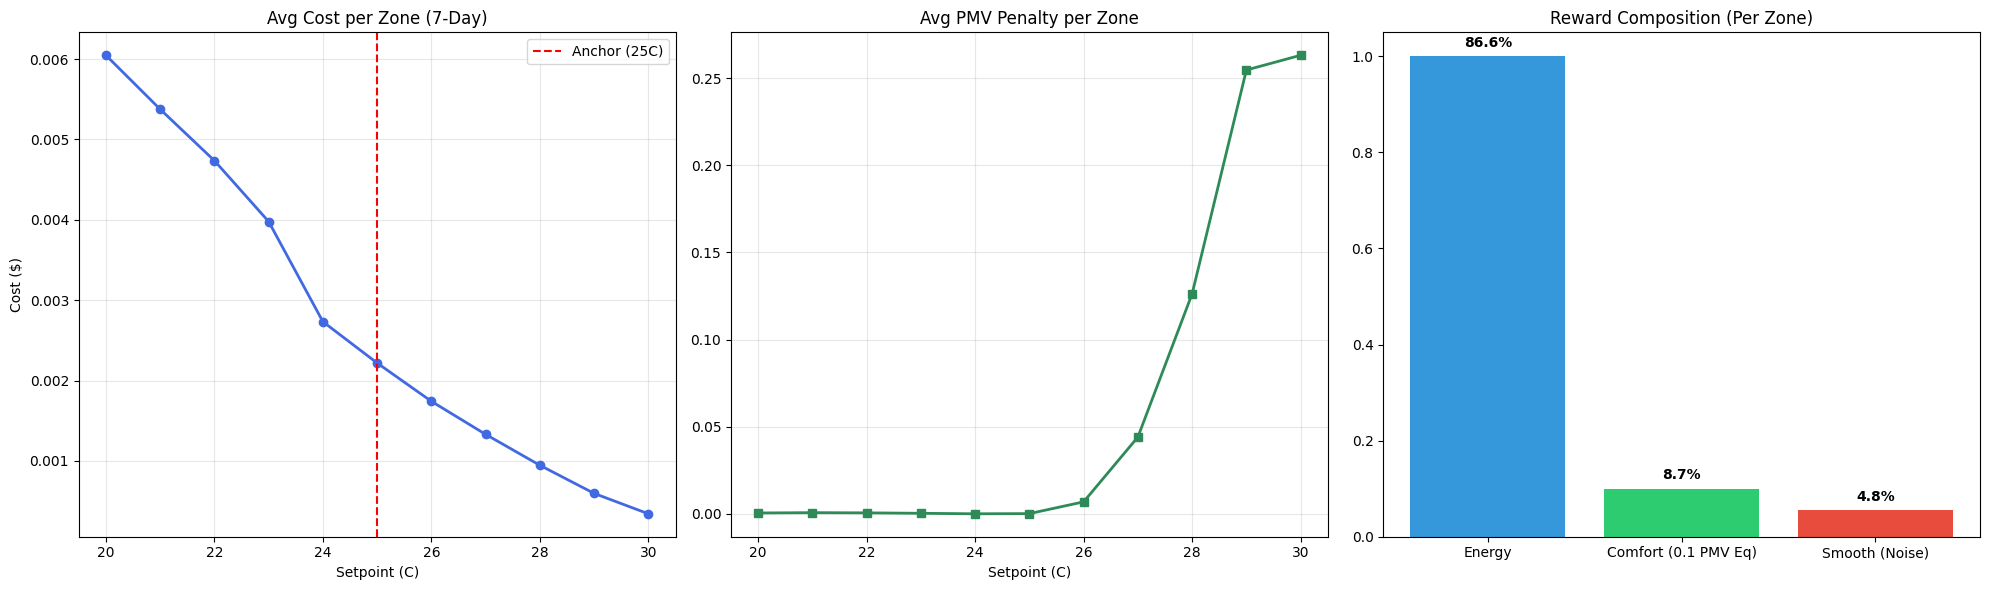

In [14]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

# 假设 config 已从对应的 config_bestest_air.py 导入
# from config_bestest_air import config

try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    print("[!] 警告: 未找到 pythermalcomfort 库，PMV 将默认返回 0。")
    pmv_ppd_iso = None

class BestestAirScalerIdentifier:
    def __init__(self, config):
        self.config = config
        self.url = config.BOPTEST_URL
        self.case = config.CASE_NAME
        
        # 1. 动态计算探测范围：直接由现有残差参数推导，不增加 config 负担
        low = config.BASE_COOLING_SETPOINT - config.RESIDUAL_ACTION_SCALE
        high = config.BASE_COOLING_SETPOINT + config.RESIDUAL_ACTION_SCALE
        self.setpoint_range = np.arange(low, high + 1.0, 1.0)
        
        self.results = []
        # 模拟 7 天，每步 15 分钟 (96步/天 * 7天 = 672步)
        self.PROBING_STEPS = 96 * 7 
        # 噪声标准差：0.25K，保证探测时存在基础抖动
        self.NOISE_STD = 0.25 

    def _get_clo(self, t_out_c):
        """动态服装热阻计算逻辑 (保持各案例对齐)"""
        params = self.config.PHYSICAL_CONFIG['clo_dynamic_params']
        if t_out_c < params['temp_low']: return params['winter_clo']
        if t_out_c > params['temp_high']: return params['summer_clo']
        ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

    def run_probing(self):
        print(f"[*] 启动 Bestest_air 系统标定 (Case: {self.case})")
        print(f"[*] 策略: 7天典型周 + 线性平滑标定 (基于 0.5C 噪声)")
        print(f"[*] 覆盖范围: {self.setpoint_range[0]}C 到 {self.setpoint_range[-1]}C")
        
        for sp in self.setpoint_range:
            print(f"    > 探测温度点: {sp} C ... ", end="", flush=True)
            
            res_sel = requests.post(f"{self.url}/testcases/{self.case}/select").json()
            tid = res_sel['testid']
            
            requests.put(f"{self.url}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.url}/step/{tid}", json={'step': self.config.CONTROL_PERIOD})
            
            start_t = self.config.START_DAY * 24 * 3600
            requests.put(f"{self.url}/initialize/{tid}", json={
                'start_time': start_t, 
                'warmup_period': 7 * 24 * 3600
            })
            
            point_data = []
            prev_u = sp 
            
            for step in range(self.PROBING_STEPS):
                # 注入噪声模拟 DRL 探索
                u_noisy = sp + np.random.normal(0, self.NOISE_STD)
                
                u_input = {
                    'con_oveTSetCoo_u': u_noisy + 273.15, 'con_oveTSetCoo_activate': 1,
                    'con_oveTSetHea_u': self.config.FIXED_HEATING_SETPOINT + 273.15, 'con_oveTSetHea_activate': 1
                }
                
                # 在 advance 之前获取预报，提取当前步真实占用人数 Occupancy[1]
                forecast_res = requests.put(f"{self.url}/forecast/{tid}", 
                                             json={'point_names': ['Occupancy[1]', 'PriceElectricPowerDynamic'], 
                                                   'horizon': 0, 'interval': self.config.CONTROL_PERIOD}).json()['payload']
                
                num_ppl = forecast_res['Occupancy[1]'][0]
                price = forecast_res['PriceElectricPowerDynamic'][0]
                
                y = requests.post(f"{self.url}/advance/{tid}", json=u_input).json()['payload']
                
                # 能耗计算: Cooling + Fan + Heating (全电)
                p_total = y.get('fcu_reaPCoo_y', 0) + y.get('fcu_reaPFan_y', 0) + y.get('fcu_reaPHea_y', 0)
                cost = (p_total * self.config.CONTROL_PERIOD / 3600000) * price
                
                # PMV 计算 (仅在占用人数 > 0 时计入惩罚)
                t_zone = y['zon_reaTRooAir_y']
                t_out = y['zon_weaSta_reaWeaTDryBul_y'] - 273.15
                pmv_p = 0
                if pmv_ppd_iso and num_ppl > 0:
                    res = pmv_ppd_iso(tdb=t_zone-273.15, tr=t_zone-273.15, vr=0.1, rh=50, met=1.1, clo=self._get_clo(t_out))
                    pmv_val = res['pmv'] if isinstance(res, dict) else res.pmv
                    pmv_p = max(0, abs(pmv_val) - 0.5)**2
                
                # 记录线性 Delta U (L1 Penalty)
                abs_du = abs(u_noisy - prev_u)
                prev_u = u_noisy
                
                point_data.append({
                    'cost': cost, 
                    'pmv_p': pmv_p, 
                    'abs_du': abs_du
                })
            
            self.results.append({
                'temp': sp,
                'avg_cost': np.mean([d['cost'] for d in point_data]),
                'avg_pmv_p': np.mean([d['pmv_p'] for d in point_data]),
                'avg_abs_du': np.mean([d['abs_du'] for d in point_data])
            })
            requests.put(f"{self.url}/stop/{tid}")
            print(f"完成")

    def calculate_scalers(self):
        df = pd.DataFrame(self.results)
        n = self.config.N_ZONES # 1.0
        
        # 锚定基准点 (25.0C)
        rbc_row = df[df['temp'] == self.config.BASE_COOLING_SETPOINT].iloc[0]
        
        # 1. 能效缩放：使单区域平均步能耗量级为 1.0
        avg_cost_per_zone = rbc_row['avg_cost'] / n
        s_energy = 1.0 / avg_cost_per_zone if avg_cost_per_zone > 0 else 1.0
        
        # 2. 舒适度缩放：基于 10% 节能交换 0.1 PMV 偏差 (0.01 惩罚) 的语义
        s_comfort = (s_energy * (0.10 * avg_cost_per_zone)) / 0.01
        
        # 3. 线性平滑缩放：统一使用“目标理想预算 0.01”作为预算分母 (5% 噪声预算)
        total_ideal_budget_per_zone = (s_energy * avg_cost_per_zone) + (s_comfort * 0.01)
        avg_abs_du_per_zone = rbc_row['avg_abs_du'] / n
        s_smooth = (0.05 * total_ideal_budget_per_zone) / avg_abs_du_per_zone if avg_abs_du_per_zone > 0 else 1.0
        
        return s_energy, s_comfort, s_smooth, df

    def plot_results(self, df, s_en, s_cm, s_sm):
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        n = self.config.N_ZONES
        
        # 图 1: 单区域平均能耗
        axes[0].plot(df['temp'], df['avg_cost'] / n, 'o-', color='royalblue', linewidth=2)
        axes[0].axvline(self.config.BASE_COOLING_SETPOINT, color='red', linestyle='--', label='Anchor (25C)')
        axes[0].set_title("Avg Cost per Zone (7-Day)", fontsize=12)
        axes[0].set_xlabel("Setpoint (C)")
        axes[0].set_ylabel("Cost ($)")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        # 图 2: 单区域平均 PMV 惩罚
        axes[1].plot(df['temp'], df['avg_pmv_p'] / n, 's-', color='seagreen', linewidth=2)
        axes[1].set_title("Avg PMV Penalty per Zone", fontsize=12)
        axes[1].set_xlabel("Setpoint (C)")
        axes[1].grid(True, alpha=0.3)

        # 图 3: 归一化后的贡献占比 (25C 点)
        rbc_row = df[df['temp'] == self.config.BASE_COOLING_SETPOINT].iloc[0]
        v_en = (rbc_row['avg_cost'] / n) * s_en
        v_cm = 0.01 * s_cm # 理想目标偏差
        v_sm = (rbc_row['avg_abs_du'] / n) * s_sm
        
        labels = ['Energy', 'Comfort (0.1 PMV Eq)', 'Smooth (Noise)']
        values = [v_en, v_cm, v_sm]
        
        axes[2].bar(labels, values, color=['#3498db', '#2ecc71', '#e74c3c'])
        axes[2].set_title("Reward Composition (Per Zone)", fontsize=12)
        
        total = sum(values)
        for i, v in enumerate(values):
            axes[2].text(i, v + 0.02, f"{(v/total)*100:.1f}%", ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig("calibration_singlezone_air.png", dpi=300)
        plt.show()

if __name__ == "__main__":
    # 执行标定逻辑
    identifier = BestestAirScalerIdentifier(config)
    identifier.run_probing()
    s_en, s_cm, s_sm, df = identifier.calculate_scalers()
    
    print("\n" + "="*60)
    print(f"      CALIBRATION RESULTS: {config.CASE_NAME}      ")
    print("="*60)
    print(f"  SCALER_ENERGY  : {s_en:.6f}")
    print(f"  SCALER_COMFORT : {s_cm:.6f}")
    print(f"  SCALER_SMOOTH  : {s_sm:.6f}")
    print("-" * 60)
    print(f"  单区域物理语义验证:")
    rbc_c = df[df['temp']==config.BASE_COOLING_SETPOINT]['avg_cost'].iloc[0] / config.N_ZONES
    print(f"  - 节省 10% 能耗对应奖励增加: +{s_en * (0.1 * rbc_c):.4f}")
    print(f"  - 0.1 PMV 偏差对应奖励惩罚: -{s_cm * 0.01:.4f}")
    print("="*60)
    
    identifier.plot_results(df, s_en, s_cm, s_sm)

# RBC

[System] pythermalcomfort loaded.
[bestest_air] Starting RBC Validation Run...
   > Start Day: 153 | Duration: 7 Days
   > Steps: 672
   > TestID: 40a463e0-e708-46c0-8aa1-38d985600c5c
   > Step 0/672 | Reward: -0.10 | PMV: 0.04
   > Step 96/672 | Reward: -0.00 | PMV: 0.65
   > Step 192/672 | Reward: -0.00 | PMV: 0.21
   > Step 288/672 | Reward: -0.00 | PMV: 0.35
   > Step 384/672 | Reward: -0.00 | PMV: 0.54
   > Step 480/672 | Reward: -0.00 | PMV: 0.46
   > Step 576/672 | Reward: -0.00 | PMV: 0.46

[Success] RBC Data Saved: bestest_air_residual_opt\data_rbc3/rbc_validation_bestest_air.csv

      RBC CALIBRATION REPORT      
Total Cost (7 Days)        : $2.79
Comfort Violations         : 34 / 287 steps
----------------------------------------
Mean Raw Cost (Occupied)   : 0.00972
Current Scaler Energy      : 450
Suggested Scaler Energy    : 51.4 (Target Norm Term ~0.5)
----------------------------------------
Avg Norm Energy Term       : 1.8683  (Ideally 0.1 - 0.5)
Avg Norm Comfort Term 

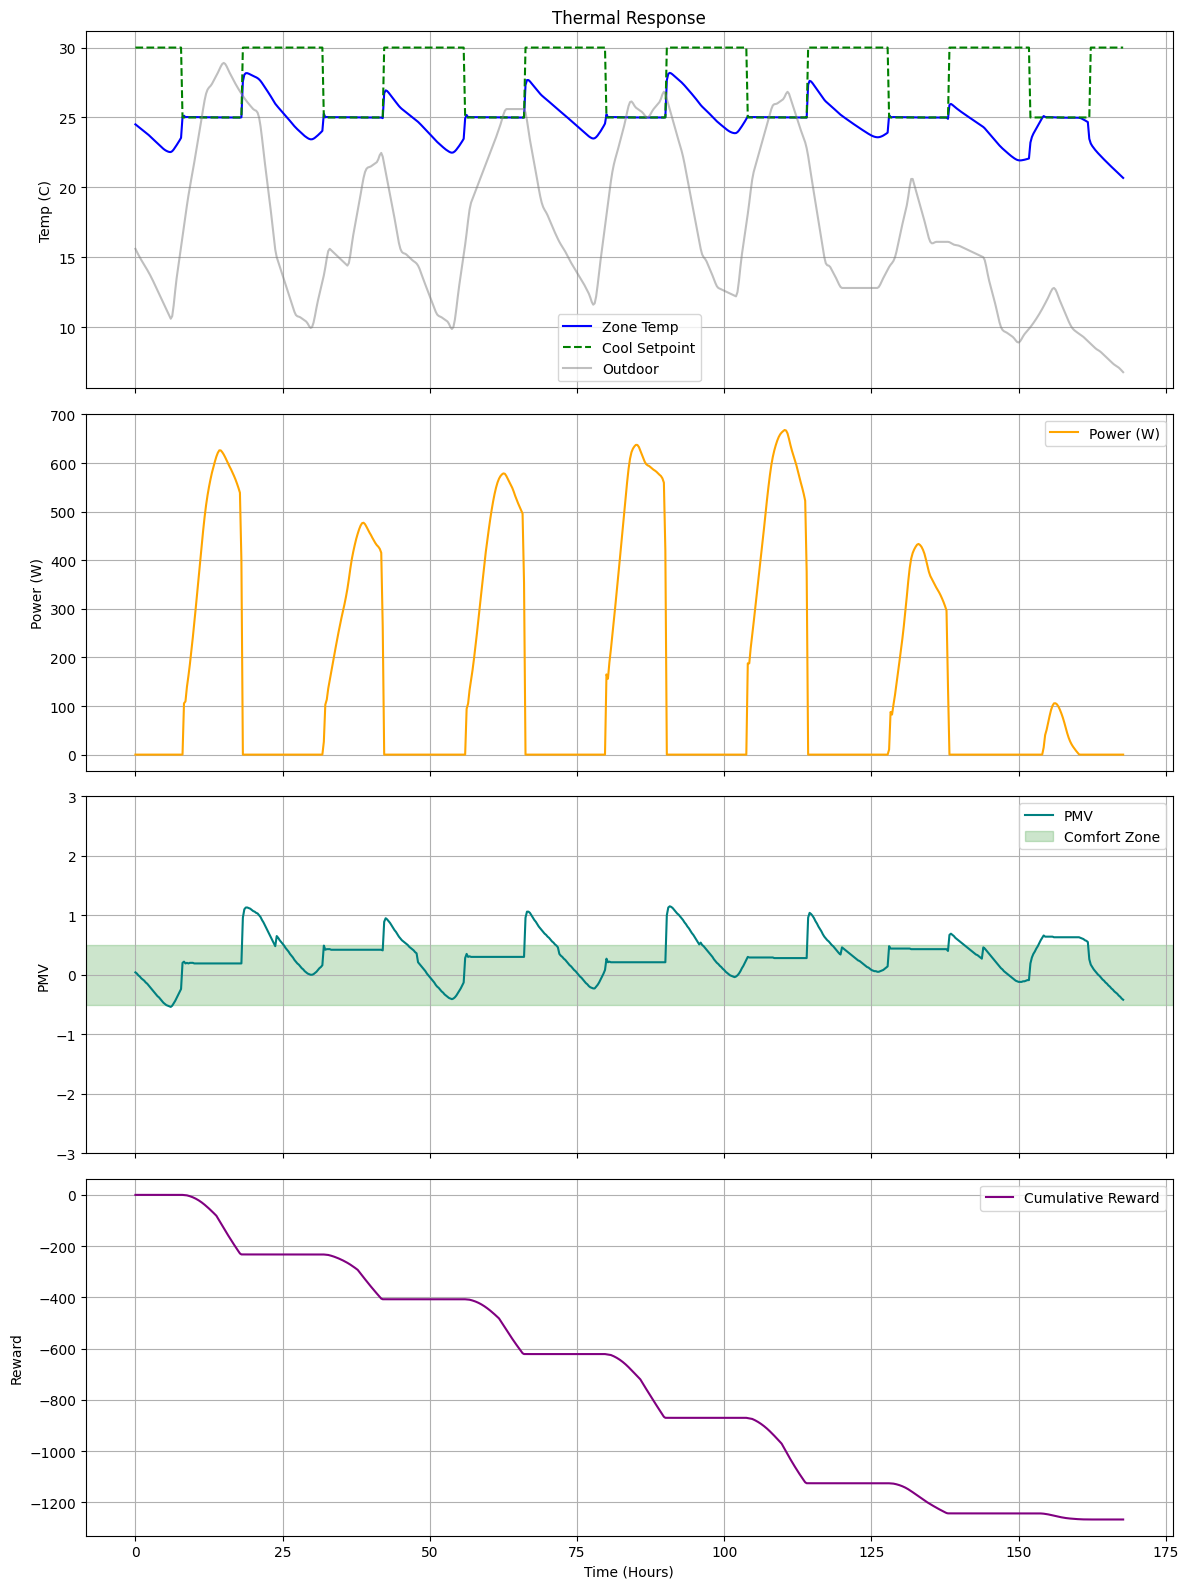

   > Stopping TestID: 40a463e0-e708-46c0-8aa1-38d985600c5c


In [34]:
# ==============================================================================
# CELL 2: RBC BASELINE COLLECTION [VALIDATION PERIOD ONLY]
#
# Logic:
#   1. Runs only the Validation Week (Day 8-14 relative to Start Day).
#   2. Implements "Occupied=24C, Unoccupied=30C" logic.
#   3. Manually constructs the "4-Past" observation history for the CSV.
#   4. Calculates detailed Reward components for Scaler calibration.
#
# Updates:
#   - Added 'sin_time' and 'cos_time' to CSV logging.
#   - Added PMV plot with comfort zone shading (-0.5 to 0.5).
#   - Refined Calibration Report to suggest Energy Scaler based on raw occupied cost.
#   - Added 'testid' tracking for all BOPTEST API calls.
# ==============================================================================
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import traceback
from collections import deque
from datetime import timedelta

# Import Physics Library
try:
    from pythermalcomfort.models import pmv_ppd_iso
    print("[System] pythermalcomfort loaded.")
except ImportError:
    print("[WARN] pythermalcomfort not found. PMV will be 0.")
    pmv_ppd_iso = None

# --- Helper: Robust Request ---
def retry_request(method, url, max_retries=5, delay=1.0, **kwargs):
    for i in range(max_retries):
        try:
            resp = requests.request(method, url, **kwargs)
            resp.raise_for_status()
            if method.lower() == 'put' and 'stop' in url: return {'status': 'stopped'} # Handle stop gracefully
            return resp.json()
        except Exception as e:
            if i == max_retries - 1:
                print(f"[Error] Request failed after {max_retries} attempts: {url}")
                raise e
            time.sleep(delay * (2 ** i))

# --- Helper: Physics ---
def calc_pmv(t_air_k, phys_config, clo):
    if pmv_ppd_iso is None: return 0.0
    t_c = t_air_k - 273.15
    try:
        res = pmv_ppd_iso(
            tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
            rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], clo=clo
        )
        return res['pmv'] if isinstance(res, dict) else res.pmv
    except: return 0.0

def get_clo(t_out_c, params):
    if t_out_c < params['temp_low']: return params['winter_clo']
    if t_out_c > params['temp_high']: return params['summer_clo']
    ratio = (t_out_c - params['temp_low']) / (params['temp_high'] - params['temp_low'])
    return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

# ==============================================================================
# Main Execution
# ==============================================================================
def run_rbc_validation():
    # 1. Setup Time (Validation Period: Start + 7 Days)
    VAL_START_DAY = config.START_DAY + 7 
    start_time = VAL_START_DAY * 24 * 3600
    duration = 7 * 24 * 3600
    steps = int(duration / config.CONTROL_PERIOD)
    
    print(f"[{config.CASE_NAME}] Starting RBC Validation Run...")
    print(f"   > Start Day: {VAL_START_DAY} | Duration: 7 Days")
    print(f"   > Steps: {steps}")

    testid = None
    try:
        # 2. Initialize BOPTEST (CRITICAL FIX: Capture testid)
        # Select Case
        sel_res = retry_request('post', f'{config.BOPTEST_URL}/testcases/{config.CASE_NAME}/select')
        testid = sel_res['testid']
        print(f"   > TestID: {testid}")
        
        # Set Parameters (Price) - Using testid
        sim_params = {'electricity_price': 'dynamic', 'gas_price': 'constant'}
        retry_request('put', f'{config.BOPTEST_URL}/scenario/{testid}', json=sim_params)
        
        # Set Step Size - Using testid
        retry_request('put', f'{config.BOPTEST_URL}/step/{testid}', json={'step': config.CONTROL_PERIOD})
        
        # Initialize - Using testid
        init_payload = {'start_time': start_time, 'warmup_period': 7*24*3600}
        init_res = retry_request('put', f'{config.BOPTEST_URL}/initialize/{testid}', json=init_payload)
        y_current = init_res['payload']
        
        # 3. History Queues (For Observation Construction)
        init_temp = y_current['zon_reaTRooAir_y']
        h_temp = deque([init_temp]*4, maxlen=4)
        h_action = deque([config.BASE_COOLING_SETPOINT + 273.15]*4, maxlen=4) 
        h_power = deque([0.0]*4, maxlen=4)
        
        # 4. Simulation Loop
        data_log = []
        total_cost = 0.0
        comfort_violation_count = 0
        occupied_count = 0
        
        current_clo = 0.5
        prev_day_idx = -1
        
        for i in range(steps):
            time_now = y_current['time']
            
            # --- Time Encoding ---
            day_seconds = time_now % 86400
            sin_time = np.sin(2 * np.pi * day_seconds / 86400)
            cos_time = np.cos(2 * np.pi * day_seconds / 86400)
            
            # --- A. Update Clo (Daily) ---
            day_idx = int(time_now // 86400)
            if day_idx != prev_day_idx:
                f_res = retry_request('put', f'{config.BOPTEST_URL}/forecast/{testid}', 
                                      json={'point_names':['TDryBul'], 'horizon':86400, 'interval':3600})
                temps = [t - 273.15 for t in f_res['payload']['TDryBul']]
                daily_mean = sum(temps) / len(temps)
                current_clo = get_clo(daily_mean, config.PHYSICAL_CONFIG['clo_dynamic_params'])
                prev_day_idx = day_idx

            # --- B. Get Forecasts ---
            f_res = retry_request('put', f'{config.BOPTEST_URL}/forecast/{testid}', 
                                  json={'point_names': config.FORECAST_POINTS, 
                                        'horizon': 4*config.CONTROL_PERIOD, 
                                        'interval': config.CONTROL_PERIOD})
            forecast = f_res['payload']
            
            occ_future = forecast['Occupancy[1]']
            occ_current = occ_future[0]
            price_elec = forecast['PriceElectricPowerDynamic'][0]
            
            # --- C. RBC Logic ---
            is_occupied = occ_current > 0
            setpoint_c = config.BASE_COOLING_SETPOINT if is_occupied else 30.0
            setpoint_k = setpoint_c + 273.15
            
            # --- D. Execute Action ---
            u = {
                'con_oveTSetCoo_u': setpoint_k, 'con_oveTSetCoo_activate': 1,
                'con_oveTSetHea_u': config.FIXED_HEATING_SETPOINT + 273.15, 'con_oveTSetHea_activate': 1
            }
            res_step = retry_request('post', f'{config.BOPTEST_URL}/advance/{testid}', json=u)
            y_next = res_step['payload']
            
            # --- E. Calculate Metrics ---
            p_cool = y_next['fcu_reaPCoo_y']
            p_fan = y_next['fcu_reaPFan_y']
            power_total = p_cool + p_fan
            energy_kwh = (power_total * config.SAMPLING_PERIOD) / 3600.0 / 1000.0
            step_cost = energy_kwh * price_elec
            total_cost += step_cost
            
            t_zone = y_next['zon_reaTRooAir_y']
            pmv = calc_pmv(t_zone, config.PHYSICAL_CONFIG, current_clo)
            
            pmv_penalty = 0.0
            if is_occupied:
                deviation = max(0, abs(pmv) - 0.5)
                pmv_penalty = deviation ** 2
                occupied_count += 1
                if deviation > 0: comfort_violation_count += 1
                
            delta_u = abs(setpoint_k - h_action[-1])
            
            # Scaler Calibration Values
            # Raw per-zone cost
            raw_cost_per_zone = step_cost / config.N_ZONES
            
            term_energy = config.REWARD_WEIGHTS['scaler_energy'] * raw_cost_per_zone
            term_comfort = config.REWARD_WEIGHTS['scaler_comfort'] * (pmv_penalty / config.N_ZONES)
            term_smooth = config.REWARD_WEIGHTS['scaler_smooth'] * (delta_u / config.N_ZONES)
            
            total_reward = - (config.REWARD_WEIGHTS['w_energy'] * term_energy + 
                              config.REWARD_WEIGHTS['w_comfort'] * term_comfort + 
                              config.REWARD_WEIGHTS['w_smooth'] * term_smooth)

            # --- F. Log Data ---
            row = {
                'time': time_now,
                'obs_sin_time': sin_time,
                'obs_cos_time': cos_time,
                'setpoint_cool': setpoint_c,
                'temp_zone': t_zone - 273.15,
                'temp_out': y_current['zon_weaSta_reaWeaTDryBul_y'] - 273.15,
                'power_total': power_total,
                'cost': step_cost,
                'raw_cost_per_zone': raw_cost_per_zone,
                'pmv': pmv,
                'obs_pp_pmv_y': pmv, # Explicit for obs
                'occupancy': occ_current,
                'is_occupied': int(is_occupied),
                'reward': total_reward,
                'term_energy_norm': term_energy,
                'term_comfort_norm': term_comfort,
                'term_smooth_norm': term_smooth,
                
                # Past States
                'obs_zon_reaTRooAir_y_past_1': h_temp[-1],
                'obs_zon_reaTRooAir_y_past_2': h_temp[-2],
                'obs_zon_reaTRooAir_y_past_3': h_temp[-3],
                'obs_zon_reaTRooAir_y_past_4': h_temp[-4],
                
                'obs_action_cool_past_1': h_action[-1],
                'obs_action_cool_past_2': h_action[-2],
                'obs_action_cool_past_3': h_action[-3],
                'obs_action_cool_past_4': h_action[-4],
                
                'obs_power_norm_past_1': h_power[-1] / config.MAX_SYSTEM_POWER,
                'obs_power_norm_past_2': h_power[-2] / config.MAX_SYSTEM_POWER,
                'obs_power_norm_past_3': h_power[-3] / config.MAX_SYSTEM_POWER,
                'obs_power_norm_past_4': h_power[-4] / config.MAX_SYSTEM_POWER,
            }
            # Add Forecasts
            for idx, pt in enumerate(['TDryBul', 'HGloHor', 'Occupancy[1]', 'PriceElectricPowerDynamic']):
                key_base = pt.replace('[1]', '')
                vals = forecast[pt]
                row[f'obs_{key_base}_current'] = vals[0]
                for fi in range(1, 5):
                    row[f'obs_{key_base}_future_{fi}'] = vals[fi]
                    
            data_log.append(row)
            
            y_current = y_next
            h_temp.append(t_zone)
            h_action.append(setpoint_k)
            h_power.append(power_total)
            
            if i % 96 == 0: print(f"   > Step {i}/{steps} | Reward: {total_reward:.2f} | PMV: {pmv:.2f}")

        # 5. Save & Visualize
        df = pd.DataFrame(data_log)
        csv_path = os.path.join(config.LOG_DIRS['rbc_data'], 'rbc_validation_bestest_air.csv')
        df.to_csv(csv_path, index=False)
        print(f"\n[Success] RBC Data Saved: {csv_path}")
        
        # --- Analysis Report (Optimized for Calibration) ---
        avg_term_en = df['term_energy_norm'].mean()
        avg_term_cm = df[df['is_occupied']==1]['term_comfort_norm'].mean()
        if pd.isna(avg_term_cm): avg_term_cm = 0.0
        
        # Calculate raw cost mean during occupied hours (for calibration)
        df_occupied = df[df['is_occupied'] == 1]
        mean_raw_cost_occ = df_occupied['raw_cost_per_zone'].mean() if not df_occupied.empty else 0.0
        
        # Target for Normalized Energy Term is 0.5
        suggested_scaler_en = 0.5 / mean_raw_cost_occ if mean_raw_cost_occ > 0 else 0
        
        print("\n" + "="*40)
        print("      RBC CALIBRATION REPORT      ")
        print("="*40)
        print(f"Total Cost (7 Days)        : ${total_cost:.2f}")
        print(f"Comfort Violations         : {comfort_violation_count} / {occupied_count} steps")
        print("-" * 40)
        print(f"Mean Raw Cost (Occupied)   : {mean_raw_cost_occ:.5f}")
        print(f"Current Scaler Energy      : {config.REWARD_WEIGHTS['scaler_energy']}")
        print(f"Suggested Scaler Energy    : {suggested_scaler_en:.1f} (Target Norm Term ~0.5)")
        print("-" * 40)
        print(f"Avg Norm Energy Term       : {avg_term_en:.4f}  (Ideally 0.1 - 0.5)")
        print(f"Avg Norm Comfort Term      : {avg_term_cm:.4f}  (Ideally < 1.0)")
        print("="*40)
        
        # --- Plotting (Updated: 4 Subplots with PMV) ---
        fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
        time_h = (df['time'] - df['time'].iloc[0]) / 3600.0
        
        # Ax1: Temperature
        axes[0].plot(time_h, df['temp_zone'], label='Zone Temp', color='blue')
        axes[0].plot(time_h, df['setpoint_cool'], label='Cool Setpoint', color='green', linestyle='--')
        axes[0].plot(time_h, df['temp_out'], label='Outdoor', color='gray', alpha=0.5)
        axes[0].set_ylabel('Temp (C)')
        axes[0].legend()
        axes[0].set_title('Thermal Response')
        axes[0].grid(True)
        
        # Ax2: Power
        axes[1].plot(time_h, df['power_total'], label='Power (W)', color='orange')
        axes[1].set_ylabel('Power (W)')
        axes[1].legend()
        axes[1].grid(True)
        
        # Ax3: PMV (New)
        axes[2].plot(time_h, df['pmv'], label='PMV', color='teal')
        axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.2, label='Comfort Zone')
        axes[2].set_ylabel('PMV')
        axes[2].set_ylim(-3, 3)
        axes[2].legend()
        axes[2].grid(True)

        # Ax4: Cumulative Reward
        cum_reward = df['reward'].cumsum()
        axes[3].plot(time_h, cum_reward, label='Cumulative Reward', color='purple')
        axes[3].set_ylabel('Reward')
        axes[3].set_xlabel('Time (Hours)')
        axes[3].legend()
        axes[3].grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(config.LOG_DIRS['results'], 'rbc_validation_plot.png'))
        plt.show()

    except Exception as e:
        print(f"\n[CRITICAL ERROR] {e}")
        traceback.print_exc()
    finally:
        # Graceful Stop
        if testid:
            print(f"   > Stopping TestID: {testid}")
            try:
                requests.put(f'{config.BOPTEST_URL}/stop/{testid}', timeout=10)
            except: pass

if __name__ == '__main__':
    run_rbc_validation()

# DRL

## 测试

In [23]:
# ==============================================================================
# CELL 3: OPTIMIZED DRL (PPO) TRAINING WITH FULL DIAGNOSTICS & LOCAL FORECAST
# ==============================================================================

import os
import gymnasium as gym
import torch
import requests
import pandas as pd
import numpy as np
import time
import traceback
import json
import gc
import subprocess
import shlex
import sys
import math
import matplotlib.pyplot as plt
from collections import deque
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

# 引入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

# 1. 定义全局总步数
total_overall_steps = config.PPO_PARAMS['n_steps'] * 4 * config.TOTAL_DRL_EPOCHS

# 2. 修改调度器逻辑，使其基于全局步数计算
def global_linear_schedule(initial_value):
    def func(progress_remaining):
        """
        progress_remaining: 从 1.0 (开始) 逐渐降到 0.0 (结束)
        逻辑：
        - 当 progress = 1.0 时，返回 initial_value * (0.9 * 1.0 + 0.1) = initial_value
        - 当 progress = 0.0 时，返回 initial_value * (0.9 * 0.0 + 0.1) = 0.1 * initial_value
        """
        return initial_value * (0.9 * progress_remaining + 0.1)
    return func
# ==============================================================================
# 1. ForecastProvider: 预取预测数据辅助类 (核心优化)
# ==============================================================================

class ForecastProvider:
    def __init__(self, config):
        self.config = config
        self.data = {}
        # 预取范围：RBC 采集天数 (14天) + 缓冲区 (1天)
        self.start_time = config.START_DAY * 24 * 3600
        self.total_horizon = (config.RBC_COLLECT_DAYS + 1) * 24 * 3600 

    def prefetch_all(self):
        print(f"\n[ForecastProvider] 正在预取全量数据 (Horizon: {self.total_horizon/3600:.1f}h)...")
        try:
            sel_url = f"{self.config.BOPTEST_URL}/testcases/{self.config.CASE_NAME}/select"
            res_sel = requests.post(sel_url, timeout=60).json()
            tid = res_sel['testid']
            
            requests.put(f"{self.config.BOPTEST_URL}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.config.BOPTEST_URL}/initialize/{tid}", 
                         json={'start_time': self.start_time, 'warmup_period': 0})
            
            f_payload = {
                'point_names': self.config.FORECAST_POINTS,
                'horizon': self.total_horizon,
                'interval': self.config.CONTROL_PERIOD
            }
            res_f = requests.put(f"{self.config.BOPTEST_URL}/forecast/{tid}", json=f_payload, timeout=120).json()
            
            if 'payload' in res_f:
                self.data = {k: np.array(v) for k, v in res_f['payload'].items()}
                print(f"[ForecastProvider] 预取成功。点位: {list(self.data.keys())}, 长度: {len(next(iter(self.data.values())))}")
            
            requests.put(f"{self.config.BOPTEST_URL}/stop/{tid}")
        except Exception as e:
            print(f"[ForecastProvider] 预取失败: {e}")
            raise e

    def get_local_forecast(self, current_time, point_name, horizon_steps=5):
        rel_time = current_time - self.start_time
        idx = int(max(0, rel_time // self.config.CONTROL_PERIOD))
        full_series = self.data.get(point_name)
        if full_series is None: return np.zeros(horizon_steps)
        vals = full_series[idx : idx + horizon_steps]
        if len(vals) < horizon_steps:
            padding = [vals[-1]] * (horizon_steps - len(vals)) if len(vals) > 0 else [0.0] * horizon_steps
            vals = np.concatenate([vals, padding])
        return vals

# ==============================================================================
# 2. 物理与辅助函数
# ==============================================================================

def safe_float(val, default=0.0):
    try:
        if val is None: return default
        f = float(val)
        return f if not (math.isnan(f) or math.isinf(f)) else default
    except: return default

def get_dynamic_clo(daily_mean_tout, params):
    t = safe_float(daily_mean_tout, 20.0)
    if t < params['temp_low']: return params['winter_clo']
    elif t > params['temp_high']: return params['summer_clo']
    else:
        ratio = (t - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

def calculate_pmv_state(t_air_k, phys_config, clo_val):
    if pmv_ppd_iso is None: return 0.0
    t_c = safe_float(t_air_k, 293.15) - 273.15
    try:
        res = pmv_ppd_iso(tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
                          rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], 
                          clo=safe_float(clo_val, 0.5))
        return safe_float(res['pmv'] if isinstance(res, dict) else res.pmv, 0.0)
    except: return 0.0

def _make_request_with_retry(method, url, rank, context_msg, max_retries=5, **kwargs):
    for attempt in range(max_retries):
        try:
            kwargs.setdefault('timeout', 90)
            response = requests.request(method, url, **kwargs)
            if response.status_code == 200:
                return response.json() if response.content else {'status': 'success'}
            # 忽略特定的 stop 错误，不进行不必要的重试
            if response.status_code == 400 and "stop" in url:
                return {'status': 'ignored_error'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 * (attempt + 1)) # 指数退避
            else:
                print(f"[Rank {rank}] {context_msg} 最终失败: {e}")
    return None

def wait_for_server_ready(config_obj, retries=60, delay=3):
    check_url = f"{config_obj.BOPTEST_URL}/version"
    for i in range(retries):
        try:
            if requests.get(check_url, timeout=10).status_code == 200:
                print(f"[SUCCESS] BOPTEST API 已就绪。")
                return
        except: pass
        time.sleep(delay)

def get_normalization_bounds(config):
    lows, highs = [], []
    for col in config.OBSERVATION_COLUMNS:
        base_key = col.replace('obs_', '')
        for s in ['_past_1', '_past_2', '_past_3', '_past_4', '_current', '_future_1', '_future_2', '_future_3', '_future_4']:
            if s in base_key: base_key = base_key.replace(s, '')
        key = 'zon_reaTRooAir_y' if 'zon_reaTRooAir_y' in base_key else \
              'Occupancy[1]' if 'Occupancy' in base_key else \
              'sin_time' if ('sin' in base_key or 'cos' in base_key) else \
              'action_cool' if 'action_cool' in base_key else \
              'power_norm' if 'power_norm' in base_key else base_key
        val_range = config.OBSERVATIONS_CONFIG.get(key, (0.0, 1.0))
        lows.append(val_range[0]); highs.append(val_range[1])
    return np.array(lows, dtype=np.float32), np.array(highs, dtype=np.float32)

class NormalizedObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.low_b, self.high_b = env.observation_space.low, env.observation_space.high
        self.range_b = self.high_b - self.low_b
        self.range_b[self.range_b == 0] = 1.0 
        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=self.observation_space.shape, dtype=np.float32)
    def observation(self, obs):
        obs = np.nan_to_num(obs, nan=0.0)
        return np.nan_to_num(2.0 * (obs - self.low_b) / self.range_b - 1.0, nan=0.0)

# ==============================================================================
# 3. DRL 环境类 (集成 ForecastProvider)
# ==============================================================================

class BestestAirResidualEnv(gym.Env):
    def __init__(self, config_obj, forecast_provider, is_validation=False, rank=0):
        super().__init__()
        self.config, self.fp, self.rank = config_obj, forecast_provider, rank
        self.url = self.config.BOPTEST_URL
        self.is_validation = is_validation
        start_day = self.config.START_DAY + 7 if is_validation else self.config.START_DAY
        self.start_time = start_day * 24 * 3600
        self.max_episode_steps = int(7 * 24 * 3600 / self.config.CONTROL_PERIOD)
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        low_b, high_b = get_normalization_bounds(self.config)
        self.observation_space = gym.spaces.Box(low=low_b, high=high_b, dtype=np.float32)
        self.testid = None
        self.history_temp, self.history_action, self.history_power = deque(maxlen=5), deque(maxlen=5), deque(maxlen=5)

    def get_observations(self, y_current):
        try:
            cur_t = safe_float(y_current.get('time', self.start_time))
            raw_obs = {}
            for point in self.config.FORECAST_POINTS:
                vals = self.fp.get_local_forecast(cur_t, point, 5)
                raw_obs[f'obs_{point}_current'] = vals[0]
                for i in range(4): raw_obs[f'obs_{point}_future_{i+1}'] = vals[i+1]
            
            t_day = cur_t % 86400
            raw_obs['obs_sin_time'], raw_obs['obs_cos_time'] = np.sin(2*np.pi*t_day/86400), np.cos(2*np.pi*t_day/86400)
            
            h_temp = list(self.history_temp)
            raw_obs['obs_zon_reaTRooAir_y'] = h_temp[-1] if h_temp else 297.15
            for i in range(1, 5): raw_obs[f'obs_zon_reaTRooAir_y_past_{i}'] = h_temp[-(i+1)] if len(h_temp) > i else h_temp[0]
            
            h_act = list(self.history_action)
            for i in range(1, 5): raw_obs[f'obs_action_cool_past_{i}'] = h_act[-(i+1)] if len(h_act) > i else h_act[0]
            
            h_pow = list(self.history_power)
            for i in range(1, 5): raw_obs[f'obs_power_norm_past_{i}'] = (h_pow[-(i+1)] if len(h_pow) > i else 0.0) / self.config.MAX_SYSTEM_POWER
            
            raw_obs['obs_pp_pmv_y'] = self.current_pmv
            return np.array([raw_obs.get(c, safe_float(y_current.get(c.replace('obs_',''), 0.0))) for c in self.config.OBSERVATION_COLUMNS], dtype=np.float32)
        except: return np.zeros(len(self.config.OBSERVATION_COLUMNS), dtype=np.float32)

    def reset(self, seed=None, options=None):
        # 1. 带有重试机制的 TestID 获取
        if self.testid is None:
            for i in range(5):
                res = _make_request_with_retry('post', f'{self.url}/testcases/{self.config.CASE_NAME}/select', self.rank, "select")
                if res and 'testid' in res:
                    self.testid = res['testid']
                    break
                time.sleep(5)
            
            if self.testid is None:
                raise RuntimeError(f"[Rank {self.rank}] 无法连接 BOPTEST，请检查 Docker。")

            _make_request_with_retry('put', f'{self.url}/step/{self.testid}', self.rank, "set_step", json={'step': self.config.CONTROL_PERIOD})
            _make_request_with_retry('put', f'{self.url}/scenario/{self.testid}', self.rank, "set_scen", json={'electricity_price': 'dynamic'})

        # 2. 带有保护的初始化
        res_init = _make_request_with_retry('put', f'{self.url}/initialize/{self.testid}', self.rank, "init", 
                                            json={'start_time': self.start_time, 'warmup_period': 7*24*3600})
        
        if not res_init or 'payload' not in res_init:
            self.testid = None # 重置以便下次彻底重启
            raise RuntimeError(f"[Rank {self.rank}] 初始化失败，响应为空。")

        y = res_init['payload']
        self.current_step, self.current_pmv, self.current_clo = 0, 0.0, 0.5
        t_init = safe_float(y.get('zon_reaTRooAir_y'), 297.15)
        self.history_temp = deque([t_init]*5, maxlen=5)
        self.history_action = deque([273.15 + 24.0]*5, maxlen=5)
        self.history_power = deque([0.0]*5, maxlen=5)
        return self.get_observations(y), {}

    def step(self, action_norm):
        cur_t = self.start_time + self.current_step * self.config.CONTROL_PERIOD
        occ = self.fp.get_local_forecast(cur_t, 'Occupancy[1]', 1)[0]
        rbc_base = 24.0 if occ > 0 else 30.0
        set_cool_k = np.clip(rbc_base + float(action_norm[0])*self.config.RESIDUAL_ACTION_SCALE + 273.15, 288.15, 303.15)
        
        res = _make_request_with_retry('post', f'{self.url}/advance/{self.testid}', self.rank, "adv", 
                                      json={'con_oveTSetCoo_u': set_cool_k, 'con_oveTSetCoo_activate': 1,
                                            'con_oveTSetHea_u': self.config.FIXED_HEATING_SETPOINT+273.15, 'con_oveTSetHea_activate': 1})
        y_next = res['payload']
        t_zone = safe_float(y_next.get('zon_reaTRooAir_y'))
        p_total = safe_float(y_next.get('fcu_reaPCoo_y', 0)) + safe_float(y_next.get('fcu_reaPFan_y', 0))
        
        if self.current_step % 96 == 0: # 每天更新一次 CLO
            tout = np.mean(self.fp.get_local_forecast(cur_t, 'TDryBul', 96)) - 273.15
            self.current_clo = get_dynamic_clo(tout, self.config.PHYSICAL_CONFIG['clo_dynamic_params'])
        
        self.current_pmv = calculate_pmv_state(t_zone, self.config.PHYSICAL_CONFIG, self.current_clo)
        price = self.fp.get_local_forecast(cur_t, 'PriceElectricPowerDynamic', 1)[0]
        cost = (p_total * self.config.CONTROL_PERIOD / 3600000) * price
        
        w, n_z = self.config.REWARD_WEIGHTS, self.config.N_ZONES
        en_r = (cost / n_z) * w['scaler_energy']
        cm_r = (max(0, abs(self.current_pmv)-0.5)**2 * w['scaler_comfort']) if occ > 0 else 0
        sm_r = (abs(set_cool_k - self.history_action[-1]) / n_z) * w['scaler_smooth']
        reward = -1.0 * (w['w_energy']*en_r + w['w_comfort']*cm_r + w['w_smooth']*sm_r)
        
        self.history_temp.append(t_zone); self.history_action.append(set_cool_k); self.history_power.append(p_total)
        self.current_step += 1
        info = {'phys_temp': t_zone-273.15, 'phys_cost': cost, 'phys_pmv_abs': abs(self.current_pmv),
                'phys_action_diff': abs(set_cool_k-self.history_action[-2]), 'setpoint': set_cool_k-273.15,
                'rew_energy': w['w_energy']*en_r, 'rew_comfort': w['w_comfort']*cm_r, 'rew_smooth': w['w_smooth']*sm_r}
        return self.get_observations(y_next), reward, False, self.current_step >= self.max_episode_steps, info

# ==============================================================================
# 4. 回调函数: 还原诊断打印、CSV日志、最佳模型保存
# ==============================================================================

class SaveOnBestTrainingRewardCallback(BaseCallback):
    def __init__(self, config_obj, verbose=1):
        super().__init__(verbose)
        self.config = config_obj
        self.save_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'best_model_ppo')
        self.log_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'ppo_training_log.csv')
        self.best_mean_reward = -np.inf
        
        # --- 核心修改：防止覆盖，载入现有日志 ---
        if os.path.exists(self.log_path):
            try:
                # 读取现有记录并转换为列表
                existing_df = pd.read_csv(self.log_path)
                self.training_log = existing_df.to_dict('records')
                # 更新 epoch_count 为现有记录的数量
                self.epoch_count = len(self.training_log)
                print(f"[Log] 发现现有日志，将从 Epoch {self.epoch_count + 1} 开始接续记录。")
                
                # 如果模型已经有过训练，尝试更新 best_mean_reward 防止重复保存
                if not existing_df.empty:
                    self.best_mean_reward = existing_df['MeanReward'].max()
            except Exception as e:
                print(f"[Log] 读取旧日志失败 ({e})，将创建新日志。")
                self.training_log = []
                self.epoch_count = 0
        else:
            self.training_log = []
            self.epoch_count = 0
            
        self.epoch_infos = []
        self.start_time = time.time()

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if 'rew_energy' in info: self.epoch_infos.append(info)
        return True

    def _on_rollout_end(self) -> bool:
        # PPO 每次 rollout 结束（对应 4 个并行环境完成了各自的 n_steps）作为一个 Epoch 计数
        self.epoch_count += 1
        ep_rewards = [ep_info['r'] for ep_info in self.model.ep_info_buffer]
        self.model.ep_info_buffer.clear()
        mean_reward = np.mean(ep_rewards) if ep_rewards else -9999
        duration = time.time() - self.start_time

        # 打印分析表格
        if self.epoch_infos:
            avg_cost = np.mean([x['phys_cost'] for x in self.epoch_infos])
            avg_pmv = np.mean([x['phys_pmv_abs'] for x in self.epoch_infos])
            avg_act = np.mean([x['phys_action_diff'] for x in self.epoch_infos])
            r_en = np.mean([x['rew_energy'] for x in self.epoch_infos])
            r_cm = np.mean([x['rew_comfort'] for x in self.epoch_infos])
            r_sm = np.mean([x['rew_smooth'] for x in self.epoch_infos])
            total_penalty = max(1e-6, r_en + r_cm + r_sm)

            print(f"\n[Epoch {self.epoch_count} Analysis]")
            print("-" * 75)
            print(f"| Component      | Raw Avg    | Weighted Avg (Contrib) |")
            print("-" * 75)
            print(f"| Energy         | $ {avg_cost:.4f}   | - {r_en:.3f}  ({r_en/total_penalty*100:.1f}%) |")
            print(f"| Comfort        | {avg_pmv:.3f} (PMV) | - {r_cm:.3f}  ({r_cm/total_penalty*100:.1f}%) |")
            print(f"| Smoothness     | {avg_act:.3f} (K)   | - {r_sm:.3f}  ({r_sm/total_penalty*100:.1f}%) |")
            print("-" * 75)
            print(f"| TOTAL REWARD   |            | {mean_reward:.3f} |")
            print("-" * 75)
            self.epoch_infos = []

        # 追加新记录
        self.training_log.append({
            'Epoch': self.epoch_count, 
            'MeanReward': mean_reward, 
            'Time': duration
        })
        
        # 保存完整日志（包含之前的记录）
        pd.DataFrame(self.training_log).to_csv(self.log_path, index=False)
        
        # 存下表现最好的模型
        if mean_reward > self.best_mean_reward:
            self.model.save(self.save_path)
            self.best_mean_reward = mean_reward
            print(f"[*] 发现更佳模型，已保存至: {self.save_path}")

        self.start_time = time.time()
        return True

# ==============================================================================
# 5. 评估与主循环
# ==============================================================================

class StopAtStepCallback(BaseCallback):
    """
    一个简单的回调，当全局步数达到指定的 stop_step 时停止训练。
    """
    def __init__(self, stop_step, verbose=0):
        super().__init__(verbose)
        self.stop_step = stop_step

    def _on_step(self) -> bool:
        # 如果当前全局步数达到了目标，返回 False 停止 learn()
        return self.num_timesteps < self.stop_step

def run_evaluation(model, epoch_idx, config_obj, fp, restart=False):
    print(f"\n[Eval] 正在运行第 {epoch_idx} Epoch 的原位验证...")
    
    # 只有在需要时才重启（例如最后一次），平时训练中途不重启
    if restart:
        restart_boptest(config_obj)
        time.sleep(15)

    # 创建一个独立的验证环境实例（不影响 vec_env）
    # rank=-1 确保它去申请一个新的 testid，而不占用训练用的 testid
    raw_env = BestestAirResidualEnv(config_obj, fp, is_validation=True, rank=-1)
    env = NormalizedObservationWrapper(raw_env)
    
    # 加载 RBC 用于对比
    rbc_path = os.path.join(config_obj.LOG_DIRS['rbc_data'], 'rbc_validation_bestest_air.csv')
    df_rbc = pd.read_csv(rbc_path)
    
    obs, _ = env.reset() # 这里会调用 initialize，把模拟时钟拨回验证周
    done, logs = False, []
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        done = term or trunc
        info['reward'] = reward 
        info['power_total'] = raw_env.history_power[-1]
        info['phys_pmv_raw'] = raw_env.current_pmv 
        info['temp_out'] = df_rbc['temp_out'].iloc[len(logs)] if len(logs) < len(df_rbc) else 0
        logs.append(info)
    
    df_drl = pd.DataFrame(logs)
    # 对齐 RBC 数据长度（以 DRL 步数为准）
    df_rbc_sync = df_rbc.iloc[:len(df_drl)].copy()
    
    time_h = np.arange(len(df_drl)) * config_obj.CONTROL_PERIOD / 3600
    
    # 开启绘图 - 采用 4 面板布局对齐 RBC 风格
    fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)
    
    # --- Panel 1: 温度响应与设定值对比 ---
    axes[0].plot(time_h, df_rbc_sync['temp_zone'], label='RBC Zone Temp', color='gray', linestyle='-', alpha=0.4)
    axes[0].plot(time_h, df_rbc_sync['setpoint_cool'], label='RBC Setpoint', color='gray', linestyle=':', alpha=0.3)
    axes[0].plot(time_h, df_drl['phys_temp'], label='DRL Zone Temp', color='blue', linewidth=1.5)
    axes[0].plot(time_h, df_drl['setpoint'], label='DRL Setpoint', color='green', linestyle='--', alpha=0.8)
    axes[0].plot(time_h, df_rbc_sync['temp_out'], label='Outdoor Temp', color='black', alpha=0.15)
    axes[0].set_ylabel('Temperature (C)')
    axes[0].set_title(f'Evaluation Report (Epoch {epoch_idx}): DRL vs RBC Baseline')
    axes[0].legend(loc='upper right', ncol=3, fontsize='small')
    axes[0].grid(True, alpha=0.3)
    
    # --- Panel 2: 功率消耗对比 ---
    axes[1].plot(time_h, df_rbc_sync['power_total'], label='RBC Power', color='orange', linestyle='--', alpha=0.4)
    axes[1].plot(time_h, df_drl['power_total'], label='DRL Power', color='darkorange', linewidth=1.5)
    axes[1].set_ylabel('Power (W)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # --- Panel 3: PMV 舒适度对比 ---
    axes[2].plot(time_h, df_rbc_sync['pmv'], label='RBC PMV', color='teal', linestyle=':', alpha=0.4)
    axes[2].plot(time_h, df_drl['phys_pmv_raw'], label='DRL PMV', color='teal', linewidth=1.5)
    axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.1, label='Comfort Zone') # 舒适区阴影
    axes[2].axhline(0, color='black', linewidth=0.5, alpha=0.5)
    axes[2].set_ylabel('PMV Index')
    axes[2].set_ylim(-2, 2)
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    
    # --- Panel 4: 累计奖励对比 ---
    axes[3].plot(time_h, df_rbc_sync['reward'].cumsum(), label='RBC CumRew', color='purple', linestyle='--', alpha=0.4)
    axes[3].plot(time_h, df_drl['reward'].cumsum(), label='DRL CumRew', color='purple', linewidth=2)
    axes[3].set_ylabel('Cumulative Reward')
    axes[3].set_xlabel('Time (Hours)')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 保存图像
    plot_filename = os.path.join(config_obj.LOG_DIRS['results'], f"eval_report_epoch_{epoch_idx}.png")
    plt.savefig(plot_filename)
    print(f"[Storage] 评估对比图像已保存至: {plot_filename}")
    
    #plt.show() 
    
    # 保存 CSV 数据
    data_filename = os.path.join(config_obj.LOG_DIRS['results'], f"eval_data_epoch_{epoch_idx}.csv")
    df_drl.to_csv(data_filename, index=False)
    print(f"[Storage] 评估原始数据已保存至: {data_filename}")

    # 打印简要对比结果
    drl_cost = df_drl['phys_cost'].sum()
    rbc_cost = df_rbc_sync['cost'].sum()
    savings = (1 - drl_cost / rbc_cost) * 100
    print(f"\n>>> 性能简报 (Epoch {epoch_idx}):")
    print(f"DRL 总成本: ${drl_cost:.2f} | RBC 总成本: ${rbc_cost:.2f}")
    print(f"当前节能率 (Energy Savings): {savings:.2f}%")

    # 清理
    if raw_env.testid: _make_request_with_retry('put', f"{config_obj.BOPTEST_URL}/stop/{raw_env.testid}", -1, "eval_stop")

def restart_boptest(config_obj):
    cwd = "C:\\project1-boptest-master"
    subprocess.run(shlex.split("docker compose down -v"), cwd=cwd, stderr=subprocess.DEVNULL)
    subprocess.run(shlex.split("docker compose up web worker provision --scale worker=5 -d"), cwd=cwd, check=True)
    wait_for_server_ready(config_obj)
    # 关键：给后端留出初始化时间
    print("[System] API 基础响应正常，等待后端服务稳定 (10s)...")
    time.sleep(10)

def main_training_loop():
    fp = ForecastProvider(config)
    fp.prefetch_all()
    diag_callback = SaveOnBestTrainingRewardCallback(config)
    
    # --- 全局参数规划 ---
    EPOCHS_PER_EVAL = 100  
    steps_per_epoch = config.PPO_PARAMS['n_steps'] * 4 
    steps_per_chunk = steps_per_epoch * EPOCHS_PER_EVAL 
    total_overall_steps = steps_per_epoch * config.TOTAL_DRL_EPOCHS
    initial_lr = config.PPO_PARAMS['learning_rate']

    print(f"\n{'='*20} 启动分段监控训练 (总目标: {config.TOTAL_DRL_EPOCHS} Epoch) {'='*20}")
    
    # 启动一次 Docker
    restart_boptest(config)
    
    # 创建并行环境
    vec_env = SubprocVecEnv([
        lambda i=i: Monitor(NormalizedObservationWrapper(BestestAirResidualEnv(config, fp, rank=i))) 
        for i in range(4)
    ])
    
    # 2. 模型加载与初始化
    model_path = os.path.join(config.LOG_DIRS['drl_models'], 'best_model_ppo.zip')
    if os.path.exists(model_path):
        print(f"[System] 检测到已有模型，正在载入...")
        model = PPO.load(model_path, env=vec_env, 
                         learning_rate=global_linear_schedule(initial_lr))
        
        # --- 核心改进：强制同步步数，防止 Epoch 倒退 ---
        # 既然日志已经到了 112，我们让模型也认为自己跑了这么多步
        expected_steps = diag_callback.epoch_count * (config.PPO_PARAMS['n_steps'] * 4)
        if model.num_timesteps < expected_steps:
            print(f"[Sync] 日志领先于模型 (Log:{diag_callback.epoch_count} > Model:84)")
            print(f"[Sync] 强制同步模型步数至: {expected_steps}")
            model.num_timesteps = expected_steps
    else:
        model = PPO('MlpPolicy', vec_env, verbose=1, seed=config.SEED, 
                    **{**config.PPO_PARAMS, 'learning_rate': global_linear_schedule(initial_lr)})

    # --- 核心逻辑：分段训练循环 ---
    while model.num_timesteps < total_overall_steps:
        # 计算本次阶段的目标截止步数
        current_step = model.num_timesteps
        next_target_step = min(current_step + steps_per_chunk, total_overall_steps)
        
        current_epoch = int(current_step / steps_per_epoch)
        print(f"\n>>> 阶段启动: Epoch {current_epoch} -> 目标截止步数: {next_target_step}")

        # 构造一个临时的停止回调
        stop_callback = StopAtStepCallback(stop_step=next_target_step)
        
        from stable_baselines3.common.callbacks import CallbackList
        # 执行训练：
        # 注意 total_timesteps 填全局总步数，这样 LR 衰减是基于 150 Epoch 的
        # callback 列表里的 stop_callback 会在跑够 20 个 Epoch 时提前终止 learn()
        model.learn(
            total_timesteps=total_overall_steps, 
            callback=CallbackList([diag_callback, stop_callback]),
            reset_num_timesteps=False
        )
        
        # --- 阶段结束，执行原位验证 ---
        # 在 main_training_loop 的循环末尾找到这部分：
        done_epoch = int(model.num_timesteps / steps_per_epoch)
        
        # --- 修改开始 ---
        best_model_path = diag_callback.save_path + ".zip" # SB3 自动加 .zip
        if os.path.exists(best_model_path):
            print(f"[*] 载入历史最佳模型进行验证...")
            eval_model = PPO.load(best_model_path)
        else:
            print("[!] 尚未产生最佳模型，使用当前模型验证...")
            eval_model = model
        
        run_evaluation(eval_model, done_epoch, config, fp, restart=False)
        # --- 修改结束 ---
        
        # 保存阶段性模型
        #model.save(os.path.join(config.LOG_DIRS['drl_models'], f"model_at_epoch_{done_epoch}"))
        print(f"[Storage] 继续下一阶段...")

    vec_env.close()
    print("\n[Success] 150 个 Epoch 的训练与分段验证全部圆满完成。")

if __name__ == '__main__':
    main_training_loop()


[ForecastProvider] 正在预取全量数据 (Horizon: 360.0h)...
[ForecastProvider] 预取成功。点位: ['time', 'Occupancy[1]', 'PriceElectricPowerDynamic', 'PriceGasPower', 'TDryBul', 'HGloHor'], 长度: 1441
[SUCCESS] BOPTEST API 已就绪。
[System] API 基础响应正常，等待后端服务稳定 (10s)...
Using cpu device

>>> 开始连续训练: 共 300 Epochs, 总计 806400 步。

[Epoch 1 Analysis]
---------------------------------------------------------------------------
| Component      | Raw Avg    | Weighted Avg (Contrib) |
---------------------------------------------------------------------------
| Energy         | $ 0.0025   | - 1.123  (65.3%) |
| Comfort        | 0.378 (PMV) | - 0.538  (31.3%) |
| Smoothness     | 2.937 (K)   | - 0.059  (3.4%) |
---------------------------------------------------------------------------
| TOTAL REWARD   |            | -1155.796 |
---------------------------------------------------------------------------
[*] 发现更佳模型，已保存至: bestest_air_residual_opt\models_drl2/best_model_ppo
-----------------------------
| time/            

NameError: name 'run_final_evaluation' is not defined

## 训练

In [7]:
# ==============================================================================
# CELL 3: OPTIMIZED DRL (PPO) TRAINING WITH FULL DIAGNOSTICS & LOCAL FORECAST
# ==============================================================================

import os
import gymnasium as gym
import torch
import requests
import pandas as pd
import numpy as np
import time
import traceback
import json
import gc
import subprocess
import shlex
import sys
import math
import matplotlib.pyplot as plt
from collections import deque
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

# 引入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

# 1. 定义全局总步数
total_overall_steps = config.PPO_PARAMS['n_steps'] * 4 * config.TOTAL_DRL_EPOCHS

# 2. 修改调度器逻辑，使其基于全局步数计算
def global_linear_schedule(initial_value):
    def func(progress_remaining):
        """
        progress_remaining: 从 1.0 (开始) 逐渐降到 0.0 (结束)
        逻辑：
        - 当 progress = 1.0 时，返回 initial_value * (0.9 * 1.0 + 0.1) = initial_value
        - 当 progress = 0.0 时，返回 initial_value * (0.9 * 0.0 + 0.1) = 0.1 * initial_value
        """
        return initial_value * (0.9 * progress_remaining + 0.1)
    return func
# ==============================================================================
# 1. ForecastProvider: 预取预测数据辅助类 (核心优化)
# ==============================================================================

class ForecastProvider:
    def __init__(self, config):
        self.config = config
        self.data = {}
        # 预取范围：RBC 采集天数 (14天) + 缓冲区 (1天)
        self.start_time = config.START_DAY * 24 * 3600
        self.total_horizon = (config.RBC_COLLECT_DAYS + 1) * 24 * 3600 

    def prefetch_all(self):
        print(f"\n[ForecastProvider] 正在预取全量数据 (Horizon: {self.total_horizon/3600:.1f}h)...")
        try:
            sel_url = f"{self.config.BOPTEST_URL}/testcases/{self.config.CASE_NAME}/select"
            res_sel = requests.post(sel_url, timeout=60).json()
            tid = res_sel['testid']
            
            requests.put(f"{self.config.BOPTEST_URL}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.config.BOPTEST_URL}/initialize/{tid}", 
                         json={'start_time': self.start_time, 'warmup_period': 0})
            
            f_payload = {
                'point_names': self.config.FORECAST_POINTS,
                'horizon': self.total_horizon,
                'interval': self.config.CONTROL_PERIOD
            }
            res_f = requests.put(f"{self.config.BOPTEST_URL}/forecast/{tid}", json=f_payload, timeout=120).json()
            
            if 'payload' in res_f:
                self.data = {k: np.array(v) for k, v in res_f['payload'].items()}
                print(f"[ForecastProvider] 预取成功。点位: {list(self.data.keys())}, 长度: {len(next(iter(self.data.values())))}")
            
            requests.put(f"{self.config.BOPTEST_URL}/stop/{tid}")
        except Exception as e:
            print(f"[ForecastProvider] 预取失败: {e}")
            raise e

    def get_local_forecast(self, current_time, point_name, horizon_steps=5):
        rel_time = current_time - self.start_time
        idx = int(max(0, rel_time // self.config.CONTROL_PERIOD))
        full_series = self.data.get(point_name)
        if full_series is None: return np.zeros(horizon_steps)
        vals = full_series[idx : idx + horizon_steps]
        if len(vals) < horizon_steps:
            padding = [vals[-1]] * (horizon_steps - len(vals)) if len(vals) > 0 else [0.0] * horizon_steps
            vals = np.concatenate([vals, padding])
        return vals

# ==============================================================================
# 2. 物理与辅助函数
# ==============================================================================

def safe_float(val, default=0.0):
    try:
        if val is None: return default
        f = float(val)
        return f if not (math.isnan(f) or math.isinf(f)) else default
    except: return default

def get_dynamic_clo(daily_mean_tout, params):
    t = safe_float(daily_mean_tout, 20.0)
    if t < params['temp_low']: return params['winter_clo']
    elif t > params['temp_high']: return params['summer_clo']
    else:
        ratio = (t - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

def calculate_pmv_state(t_air_k, phys_config, clo_val):
    if pmv_ppd_iso is None: return 0.0
    t_c = safe_float(t_air_k, 293.15) - 273.15
    try:
        res = pmv_ppd_iso(tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
                          rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], 
                          clo=safe_float(clo_val, 0.5))
        return safe_float(res['pmv'] if isinstance(res, dict) else res.pmv, 0.0)
    except: return 0.0

def _make_request_with_retry(method, url, rank, context_msg, max_retries=5, **kwargs):
    for attempt in range(max_retries):
        try:
            kwargs.setdefault('timeout', 90)
            response = requests.request(method, url, **kwargs)
            if response.status_code == 200:
                return response.json() if response.content else {'status': 'success'}
            # 忽略特定的 stop 错误，不进行不必要的重试
            if response.status_code == 400 and "stop" in url:
                return {'status': 'ignored_error'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 * (attempt + 1)) # 指数退避
            else:
                print(f"[Rank {rank}] {context_msg} 最终失败: {e}")
    return None

def wait_for_server_ready(config_obj, retries=60, delay=3):
    check_url = f"{config_obj.BOPTEST_URL}/version"
    for i in range(retries):
        try:
            if requests.get(check_url, timeout=10).status_code == 200:
                print(f"[SUCCESS] BOPTEST API 已就绪。")
                return
        except: pass
        time.sleep(delay)

def get_normalization_bounds(config):
    lows, highs = [], []
    for col in config.OBSERVATION_COLUMNS:
        base_key = col.replace('obs_', '')
        for s in ['_past_1', '_past_2', '_past_3', '_past_4', '_current', '_future_1', '_future_2', '_future_3', '_future_4']:
            if s in base_key: base_key = base_key.replace(s, '')
        key = 'zon_reaTRooAir_y' if 'zon_reaTRooAir_y' in base_key else \
              'Occupancy[1]' if 'Occupancy' in base_key else \
              'sin_time' if ('sin' in base_key or 'cos' in base_key) else \
              'action_cool' if 'action_cool' in base_key else \
              'power_norm' if 'power_norm' in base_key else base_key
        val_range = config.OBSERVATIONS_CONFIG.get(key, (0.0, 1.0))
        lows.append(val_range[0]); highs.append(val_range[1])
    return np.array(lows, dtype=np.float32), np.array(highs, dtype=np.float32)

class NormalizedObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.low_b, self.high_b = env.observation_space.low, env.observation_space.high
        self.range_b = self.high_b - self.low_b
        self.range_b[self.range_b == 0] = 1.0 
        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=self.observation_space.shape, dtype=np.float32)
    def observation(self, obs):
        obs = np.nan_to_num(obs, nan=0.0)
        return np.nan_to_num(2.0 * (obs - self.low_b) / self.range_b - 1.0, nan=0.0)

# ==============================================================================
# 3. DRL 环境类 (集成 ForecastProvider)
# ==============================================================================

class BestestAirResidualEnv(gym.Env):
    def __init__(self, config_obj, forecast_provider, is_validation=False, rank=0):
        super().__init__()
        self.config, self.fp, self.rank = config_obj, forecast_provider, rank
        self.url = self.config.BOPTEST_URL
        self.is_validation = is_validation
        start_day = self.config.START_DAY + 7 if is_validation else self.config.START_DAY
        self.start_time = start_day * 24 * 3600
        self.max_episode_steps = int(7 * 24 * 3600 / self.config.CONTROL_PERIOD)
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        low_b, high_b = get_normalization_bounds(self.config)
        self.observation_space = gym.spaces.Box(low=low_b, high=high_b, dtype=np.float32)
        self.testid = None
        self.history_temp, self.history_action, self.history_power = deque(maxlen=5), deque(maxlen=5), deque(maxlen=5)

    def get_observations(self, y_current):
        try:
            cur_t = safe_float(y_current.get('time', self.start_time))
            raw_obs = {}
            for point in self.config.FORECAST_POINTS:
                vals = self.fp.get_local_forecast(cur_t, point, 5)
                raw_obs[f'obs_{point}_current'] = vals[0]
                for i in range(4): raw_obs[f'obs_{point}_future_{i+1}'] = vals[i+1]
            
            t_day = cur_t % 86400
            raw_obs['obs_sin_time'], raw_obs['obs_cos_time'] = np.sin(2*np.pi*t_day/86400), np.cos(2*np.pi*t_day/86400)
            
            h_temp = list(self.history_temp)
            raw_obs['obs_zon_reaTRooAir_y'] = h_temp[-1] if h_temp else 297.15
            for i in range(1, 5): raw_obs[f'obs_zon_reaTRooAir_y_past_{i}'] = h_temp[-(i+1)] if len(h_temp) > i else h_temp[0]
            
            h_act = list(self.history_action)
            for i in range(1, 5): raw_obs[f'obs_action_cool_past_{i}'] = h_act[-(i+1)] if len(h_act) > i else h_act[0]
            
            h_pow = list(self.history_power)
            for i in range(1, 5): raw_obs[f'obs_power_norm_past_{i}'] = (h_pow[-(i+1)] if len(h_pow) > i else 0.0) / self.config.MAX_SYSTEM_POWER
            
            raw_obs['obs_pp_pmv_y'] = self.current_pmv
            return np.array([raw_obs.get(c, safe_float(y_current.get(c.replace('obs_',''), 0.0))) for c in self.config.OBSERVATION_COLUMNS], dtype=np.float32)
        except: return np.zeros(len(self.config.OBSERVATION_COLUMNS), dtype=np.float32)

    def reset(self, seed=None, options=None):
        # 1. 带有重试机制的 TestID 获取
        if self.testid is None:
            for i in range(5):
                res = _make_request_with_retry('post', f'{self.url}/testcases/{self.config.CASE_NAME}/select', self.rank, "select")
                if res and 'testid' in res:
                    self.testid = res['testid']
                    break
                time.sleep(5)
            
            if self.testid is None:
                raise RuntimeError(f"[Rank {self.rank}] 无法连接 BOPTEST，请检查 Docker。")

            _make_request_with_retry('put', f'{self.url}/step/{self.testid}', self.rank, "set_step", json={'step': self.config.CONTROL_PERIOD})
            _make_request_with_retry('put', f'{self.url}/scenario/{self.testid}', self.rank, "set_scen", json={'electricity_price': 'dynamic'})

        # 2. 带有保护的初始化
        res_init = _make_request_with_retry('put', f'{self.url}/initialize/{self.testid}', self.rank, "init", 
                                            json={'start_time': self.start_time, 'warmup_period': 7*24*3600})
        
        if not res_init or 'payload' not in res_init:
            self.testid = None # 重置以便下次彻底重启
            raise RuntimeError(f"[Rank {self.rank}] 初始化失败，响应为空。")

        y = res_init['payload']
        self.current_step, self.current_pmv, self.current_clo = 0, 0.0, 0.5
        t_init = safe_float(y.get('zon_reaTRooAir_y'), 297.15)
        self.history_temp = deque([t_init]*5, maxlen=5)
        self.history_action = deque([273.15 + 24.0]*5, maxlen=5)
        self.history_power = deque([0.0]*5, maxlen=5)
        return self.get_observations(y), {}

    def step(self, action_norm):
        cur_t = self.start_time + self.current_step * self.config.CONTROL_PERIOD
        occ = self.fp.get_local_forecast(cur_t, 'Occupancy[1]', 1)[0]
        rbc_base = 25.0
        set_cool_k = np.clip(rbc_base + float(action_norm[0])*self.config.RESIDUAL_ACTION_SCALE + 273.15, 288.15, 303.15)
        
        res = _make_request_with_retry('post', f'{self.url}/advance/{self.testid}', self.rank, "adv", 
                                      json={'con_oveTSetCoo_u': set_cool_k, 'con_oveTSetCoo_activate': 1,
                                            'fcu_oveTSup_u': 290.15, 'fcu_oveTSup_activate': 1,
                                            'con_oveTSetHea_u': self.config.FIXED_HEATING_SETPOINT+273.15, 'con_oveTSetHea_activate': 1})
        y_next = res['payload']
        t_zone = safe_float(y_next.get('zon_reaTRooAir_y'))
        p_total = safe_float(y_next.get('fcu_reaPCoo_y', 0)) + safe_float(y_next.get('fcu_reaPFan_y', 0))
        
        if self.current_step % 96 == 0: # 每天更新一次 CLO
            tout = np.mean(self.fp.get_local_forecast(cur_t, 'TDryBul', 96)) - 273.15
            self.current_clo = get_dynamic_clo(tout, self.config.PHYSICAL_CONFIG['clo_dynamic_params'])
        
        self.current_pmv = calculate_pmv_state(t_zone, self.config.PHYSICAL_CONFIG, self.current_clo)
        price = self.fp.get_local_forecast(cur_t, 'PriceElectricPowerDynamic', 1)[0]
        cost = (p_total * self.config.CONTROL_PERIOD / 3600000) * price
        
        w, n_z = self.config.REWARD_WEIGHTS, self.config.N_ZONES
        en_r = (cost / n_z) * w['scaler_energy']
        cm_r = (max(0, abs(self.current_pmv)-0.5)**2 * w['scaler_comfort']) if occ > 0 else 0
        sm_r = (abs(set_cool_k - self.history_action[-1]) / n_z) * w['scaler_smooth']
        reward = -1.0 * (w['w_energy']*en_r + w['w_comfort']*cm_r + w['w_smooth']*sm_r)
        
        self.history_temp.append(t_zone); self.history_action.append(set_cool_k); self.history_power.append(p_total)
        self.current_step += 1
        info = {'phys_temp': t_zone-273.15, 'phys_cost': cost, 'phys_pmv_abs': abs(self.current_pmv),
                'phys_action_diff': abs(set_cool_k-self.history_action[-2]), 'setpoint': set_cool_k-273.15,
                'rew_energy': w['w_energy']*en_r, 'rew_comfort': w['w_comfort']*cm_r, 'rew_smooth': w['w_smooth']*sm_r}
        return self.get_observations(y_next), reward, False, self.current_step >= self.max_episode_steps, info

# ==============================================================================
# 4. 回调函数: 还原诊断打印、CSV日志、最佳模型保存
# ==============================================================================

class SaveOnBestTrainingRewardCallback(BaseCallback):
    def __init__(self, config_obj, verbose=1):
        super().__init__(verbose)
        self.config = config_obj
        self.save_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'best_model_ppo')
        self.log_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'ppo_training_log.csv')
        self.best_mean_reward = -np.inf
        
        # --- 核心修改：防止覆盖，载入现有日志 ---
        if os.path.exists(self.log_path):
            try:
                # 读取现有记录并转换为列表
                existing_df = pd.read_csv(self.log_path)
                self.training_log = existing_df.to_dict('records')
                # 更新 epoch_count 为现有记录的数量
                self.epoch_count = len(self.training_log)
                print(f"[Log] 发现现有日志，将从 Epoch {self.epoch_count + 1} 开始接续记录。")
                
                # 如果模型已经有过训练，尝试更新 best_mean_reward 防止重复保存
                if not existing_df.empty:
                    self.best_mean_reward = existing_df['MeanReward'].max()
            except Exception as e:
                print(f"[Log] 读取旧日志失败 ({e})，将创建新日志。")
                self.training_log = []
                self.epoch_count = 0
        else:
            self.training_log = []
            self.epoch_count = 0
            
        self.epoch_infos = []
        self.start_time = time.time()

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if 'rew_energy' in info: self.epoch_infos.append(info)
        return True

    def _on_rollout_end(self) -> bool:
        # PPO 每次 rollout 结束（对应 4 个并行环境完成了各自的 n_steps）作为一个 Epoch 计数
        self.epoch_count += 1
        ep_rewards = [ep_info['r'] for ep_info in self.model.ep_info_buffer]
        self.model.ep_info_buffer.clear()
        mean_reward = np.mean(ep_rewards) if ep_rewards else -9999
        duration = time.time() - self.start_time

        # 打印分析表格
        if self.epoch_infos:
            avg_cost = np.mean([x['phys_cost'] for x in self.epoch_infos])
            avg_pmv = np.mean([x['phys_pmv_abs'] for x in self.epoch_infos])
            avg_act = np.mean([x['phys_action_diff'] for x in self.epoch_infos])
            r_en = np.mean([x['rew_energy'] for x in self.epoch_infos])
            r_cm = np.mean([x['rew_comfort'] for x in self.epoch_infos])
            r_sm = np.mean([x['rew_smooth'] for x in self.epoch_infos])
            total_penalty = max(1e-6, r_en + r_cm + r_sm)

            print(f"\n[Epoch {self.epoch_count} Analysis]")
            print("-" * 75)
            print(f"| Component      | Raw Avg    | Weighted Avg (Contrib) |")
            print("-" * 75)
            print(f"| Energy         | $ {avg_cost:.4f}   | - {r_en:.3f}  ({r_en/total_penalty*100:.1f}%) |")
            print(f"| Comfort        | {avg_pmv:.3f} (PMV) | - {r_cm:.3f}  ({r_cm/total_penalty*100:.1f}%) |")
            print(f"| Smoothness     | {avg_act:.3f} (K)   | - {r_sm:.3f}  ({r_sm/total_penalty*100:.1f}%) |")
            print("-" * 75)
            print(f"| TOTAL REWARD   |            | {mean_reward:.3f} |")
            print("-" * 75)
            self.epoch_infos = []

        # 追加新记录
        self.training_log.append({
            'Epoch': self.epoch_count, 
            'MeanReward': mean_reward, 
            'Time': duration
        })
        
        # 保存完整日志（包含之前的记录）
        pd.DataFrame(self.training_log).to_csv(self.log_path, index=False)
        
        # 存下表现最好的模型
        if mean_reward > self.best_mean_reward:
            self.model.save(self.save_path)
            self.best_mean_reward = mean_reward
            print(f"[*] 发现更佳模型，已保存至: {self.save_path}")

        self.start_time = time.time()
        return True

# ==============================================================================
# 5. 评估与主循环
# ==============================================================================

class StopAtStepCallback(BaseCallback):
    """
    一个简单的回调，当全局步数达到指定的 stop_step 时停止训练。
    """
    def __init__(self, stop_step, verbose=0):
        super().__init__(verbose)
        self.stop_step = stop_step

    def _on_step(self) -> bool:
        # 如果当前全局步数达到了目标，返回 False 停止 learn()
        return self.num_timesteps < self.stop_step

def run_evaluation(model, epoch_idx, config_obj, fp, restart=False):
    print(f"\n[Eval] 正在运行第 {epoch_idx} Epoch 的原位验证...")
    
    # 只有在需要时才重启（例如最后一次），平时训练中途不重启
    if restart:
        restart_boptest(config_obj)
        time.sleep(15)

    # 创建一个独立的验证环境实例（不影响 vec_env）
    # rank=-1 确保它去申请一个新的 testid，而不占用训练用的 testid
    raw_env = BestestAirResidualEnv(config_obj, fp, is_validation=True, rank=-1)
    env = NormalizedObservationWrapper(raw_env)
    
    # 加载 RBC 用于对比
    rbc_path = os.path.join(config_obj.LOG_DIRS['rbc_data'], 'rbc_validation_bestest_air.csv')
    df_rbc = pd.read_csv(rbc_path)
    
    obs, _ = env.reset() # 这里会调用 initialize，把模拟时钟拨回验证周
    done, logs = False, []
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        done = term or trunc
        info['reward'] = reward 
        info['power_total'] = raw_env.history_power[-1]
        info['phys_pmv_raw'] = raw_env.current_pmv 
        info['temp_out'] = df_rbc['temp_out'].iloc[len(logs)] if len(logs) < len(df_rbc) else 0
        logs.append(info)
    
    df_drl = pd.DataFrame(logs)
    # 对齐 RBC 数据长度（以 DRL 步数为准）
    df_rbc_sync = df_rbc.iloc[:len(df_drl)].copy()
    
    time_h = np.arange(len(df_drl)) * config_obj.CONTROL_PERIOD / 3600
    
    # 开启绘图 - 采用 4 面板布局对齐 RBC 风格
    fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)
    
    # --- Panel 1: 温度响应与设定值对比 ---
    axes[0].plot(time_h, df_rbc_sync['temp_zone'], label='RBC Zone Temp', color='gray', linestyle='-', alpha=0.4)
    axes[0].plot(time_h, df_rbc_sync['setpoint_cool'], label='RBC Setpoint', color='gray', linestyle=':', alpha=0.3)
    axes[0].plot(time_h, df_drl['phys_temp'], label='DRL Zone Temp', color='blue', linewidth=1.5)
    axes[0].plot(time_h, df_drl['setpoint'], label='DRL Setpoint', color='green', linestyle='--', alpha=0.8)
    axes[0].plot(time_h, df_rbc_sync['temp_out'], label='Outdoor Temp', color='black', alpha=0.15)
    axes[0].set_ylabel('Temperature (C)')
    axes[0].set_title(f'Evaluation Report (Epoch {epoch_idx}): DRL vs RBC Baseline')
    axes[0].legend(loc='upper right', ncol=3, fontsize='small')
    axes[0].grid(True, alpha=0.3)
    
    # --- Panel 2: 功率消耗对比 ---
    axes[1].plot(time_h, df_rbc_sync['power_total'], label='RBC Power', color='orange', linestyle='--', alpha=0.4)
    axes[1].plot(time_h, df_drl['power_total'], label='DRL Power', color='darkorange', linewidth=1.5)
    axes[1].set_ylabel('Power (W)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # --- Panel 3: PMV 舒适度对比 ---
    axes[2].plot(time_h, df_rbc_sync['pmv'], label='RBC PMV', color='teal', linestyle=':', alpha=0.4)
    axes[2].plot(time_h, df_drl['phys_pmv_raw'], label='DRL PMV', color='teal', linewidth=1.5)
    axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.1, label='Comfort Zone') # 舒适区阴影
    axes[2].axhline(0, color='black', linewidth=0.5, alpha=0.5)
    axes[2].set_ylabel('PMV Index')
    axes[2].set_ylim(-2, 2)
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    
    # --- Panel 4: 累计奖励对比 ---
    axes[3].plot(time_h, df_rbc_sync['reward'].cumsum(), label='RBC CumRew', color='purple', linestyle='--', alpha=0.4)
    axes[3].plot(time_h, df_drl['reward'].cumsum(), label='DRL CumRew', color='purple', linewidth=2)
    axes[3].set_ylabel('Cumulative Reward')
    axes[3].set_xlabel('Time (Hours)')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 保存图像
    plot_filename = os.path.join(config_obj.LOG_DIRS['results'], f"eval_report_epoch_{epoch_idx}.png")
    plt.savefig(plot_filename)
    print(f"[Storage] 评估对比图像已保存至: {plot_filename}")
    
    #plt.show() 
    
    # 保存 CSV 数据
    data_filename = os.path.join(config_obj.LOG_DIRS['results'], f"eval_data_epoch_{epoch_idx}.csv")
    df_drl.to_csv(data_filename, index=False)
    print(f"[Storage] 评估原始数据已保存至: {data_filename}")

    # 打印简要对比结果
    drl_cost = df_drl['phys_cost'].sum()
    rbc_cost = df_rbc_sync['cost'].sum()
    savings = (1 - drl_cost / rbc_cost) * 100
    print(f"\n>>> 性能简报 (Epoch {epoch_idx}):")
    print(f"DRL 总成本: ${drl_cost:.2f} | RBC 总成本: ${rbc_cost:.2f}")
    print(f"当前节能率 (Energy Savings): {savings:.2f}%")

    # 清理
    if raw_env.testid: _make_request_with_retry('put', f"{config_obj.BOPTEST_URL}/stop/{raw_env.testid}", -1, "eval_stop")

def restart_boptest(config_obj):
    cwd = "C:\\project1-boptest-master"
    subprocess.run(shlex.split("docker compose down -v"), cwd=cwd, stderr=subprocess.DEVNULL)
    subprocess.run(shlex.split("docker compose up web worker provision --scale worker=5 -d"), cwd=cwd, check=True)
    wait_for_server_ready(config_obj)
    # 关键：给后端留出初始化时间
    print("[System] API 基础响应正常，等待后端服务稳定 (10s)...")
    time.sleep(10)

def main_training_loop():
    # 1. 准备工作
    fp = ForecastProvider(config)
    fp.prefetch_all()
    restart_boptest(config)
    
    # 2. 创建并行训练环境
    vec_env = SubprocVecEnv([
        lambda i=i: Monitor(NormalizedObservationWrapper(BestestAirResidualEnv(config, fp, rank=i))) 
        for i in range(4)
    ])
    
    # 3. 规划总步数
    steps_per_epoch = config.PPO_PARAMS['n_steps'] * 4
    total_overall_steps = steps_per_epoch * config.TOTAL_DRL_EPOCHS
    
    # 4. 模型实例化
    model = PPO('MlpPolicy', vec_env, verbose=1, seed=config.SEED, 
                **{**config.PPO_PARAMS, 'learning_rate': global_linear_schedule(config.PPO_PARAMS['learning_rate'])})
    
    diag_callback = SaveOnBestTrainingRewardCallback(config)
    
    print(f"\n>>> 开始连续训练: 共 {config.TOTAL_DRL_EPOCHS} Epochs, 总计 {total_overall_steps} 步。")
    
    # 5. 执行一次性完整训练
    try:
        model.learn(
            total_timesteps=total_overall_steps,
            callback=diag_callback,
            reset_num_timesteps=True
        )
    except Exception as e:
        print(f"[Fatal] 训练异常中断: {e}")
        traceback.print_exc()
    finally:
        # 先关闭训练环境释放资源
        vec_env.close()
    
    # # --- 关键修正位置：在 learn 结束后正确执行评估 ---
    # best_zip = diag_callback.save_path + ".zip"
    # if os.path.exists(best_zip):
    #     print(f"[*] 训练完成。正在载入历史最佳模型进行最终绘图评估...")
    #     # 修正 1: 必须先从硬盘加载 PPO 模型对象
    #     final_best_model = PPO.load(best_zip)
        
    #     # 修正 2: 严格按照定义传递参数 (model, epoch_idx, config_obj, fp)
    #     # 定义：def run_evaluation(model, epoch_idx, config_obj, fp, restart=False):
    #     # run_evaluation(
    #     #     model=final_best_model, 
    #     #     epoch_idx=config.TOTAL_DRL_EPOCHS, 
    #     #     config_obj=config, 
    #     #     fp=fp, 
    #     #     restart=False
    #     # )
    # else:
    #     print("[Warning] 未找到保存的最佳模型，跳过最终验证。")

if __name__ == '__main__':
    main_training_loop()


[ForecastProvider] 正在预取全量数据 (Horizon: 360.0h)...
[ForecastProvider] 预取成功。点位: ['time', 'Occupancy[1]', 'PriceElectricPowerDynamic', 'PriceGasPower', 'TDryBul', 'HGloHor'], 长度: 1441
[SUCCESS] BOPTEST API 已就绪。
[System] API 基础响应正常，等待后端服务稳定 (10s)...
Using cpu device

>>> 开始连续训练: 共 300 Epochs, 总计 806400 步。

[Epoch 1 Analysis]
---------------------------------------------------------------------------
| Component      | Raw Avg    | Weighted Avg (Contrib) |
---------------------------------------------------------------------------
| Energy         | $ 0.0085   | - 1.017  (6.4%) |
| Comfort        | 0.663 (PMV) | - 14.698  (93.1%) |
| Smoothness     | 4.114 (K)   | - 0.074  (0.5%) |
---------------------------------------------------------------------------
| TOTAL REWARD   |            | -10610.212 |
---------------------------------------------------------------------------
[*] 发现更佳模型，已保存至: bestest_air_residual_opt\models_drl4/best_model_ppo
-----------------------------
| time/           

# 绘图


[ForecastProvider] 正在预取全量数据 (Horizon: 360.0h)...
[ForecastProvider] 预取成功。点位: ['time', 'Occupancy[1]', 'PriceElectricPowerDynamic', 'PriceGasPower', 'TDryBul', 'HGloHor'], 长度: 1441
[SUCCESS] BOPTEST API 已就绪。
[System] API 基础响应正常，等待后端服务稳定 (10s)...
Using cpu device

>>> 开始连续训练: 共 500 Epochs, 总计 1344000 步。

[Epoch 1 Analysis]
---------------------------------------------------------------------------
| Component      | Raw Avg    | Weighted Avg (Contrib) |
---------------------------------------------------------------------------
| Energy         | $ 0.0025   | - 1.123  (59.1%) |
| Comfort        | 0.378 (PMV) | - 0.717  (37.8%) |
| Smoothness     | 2.937 (K)   | - 0.059  (3.1%) |
---------------------------------------------------------------------------
| TOTAL REWARD   |            | -1276.330 |
---------------------------------------------------------------------------
[*] 发现更佳模型，已保存至: bestest_air_residual_opt\models_drl3/best_model_ppo
-----------------------------
| time/           

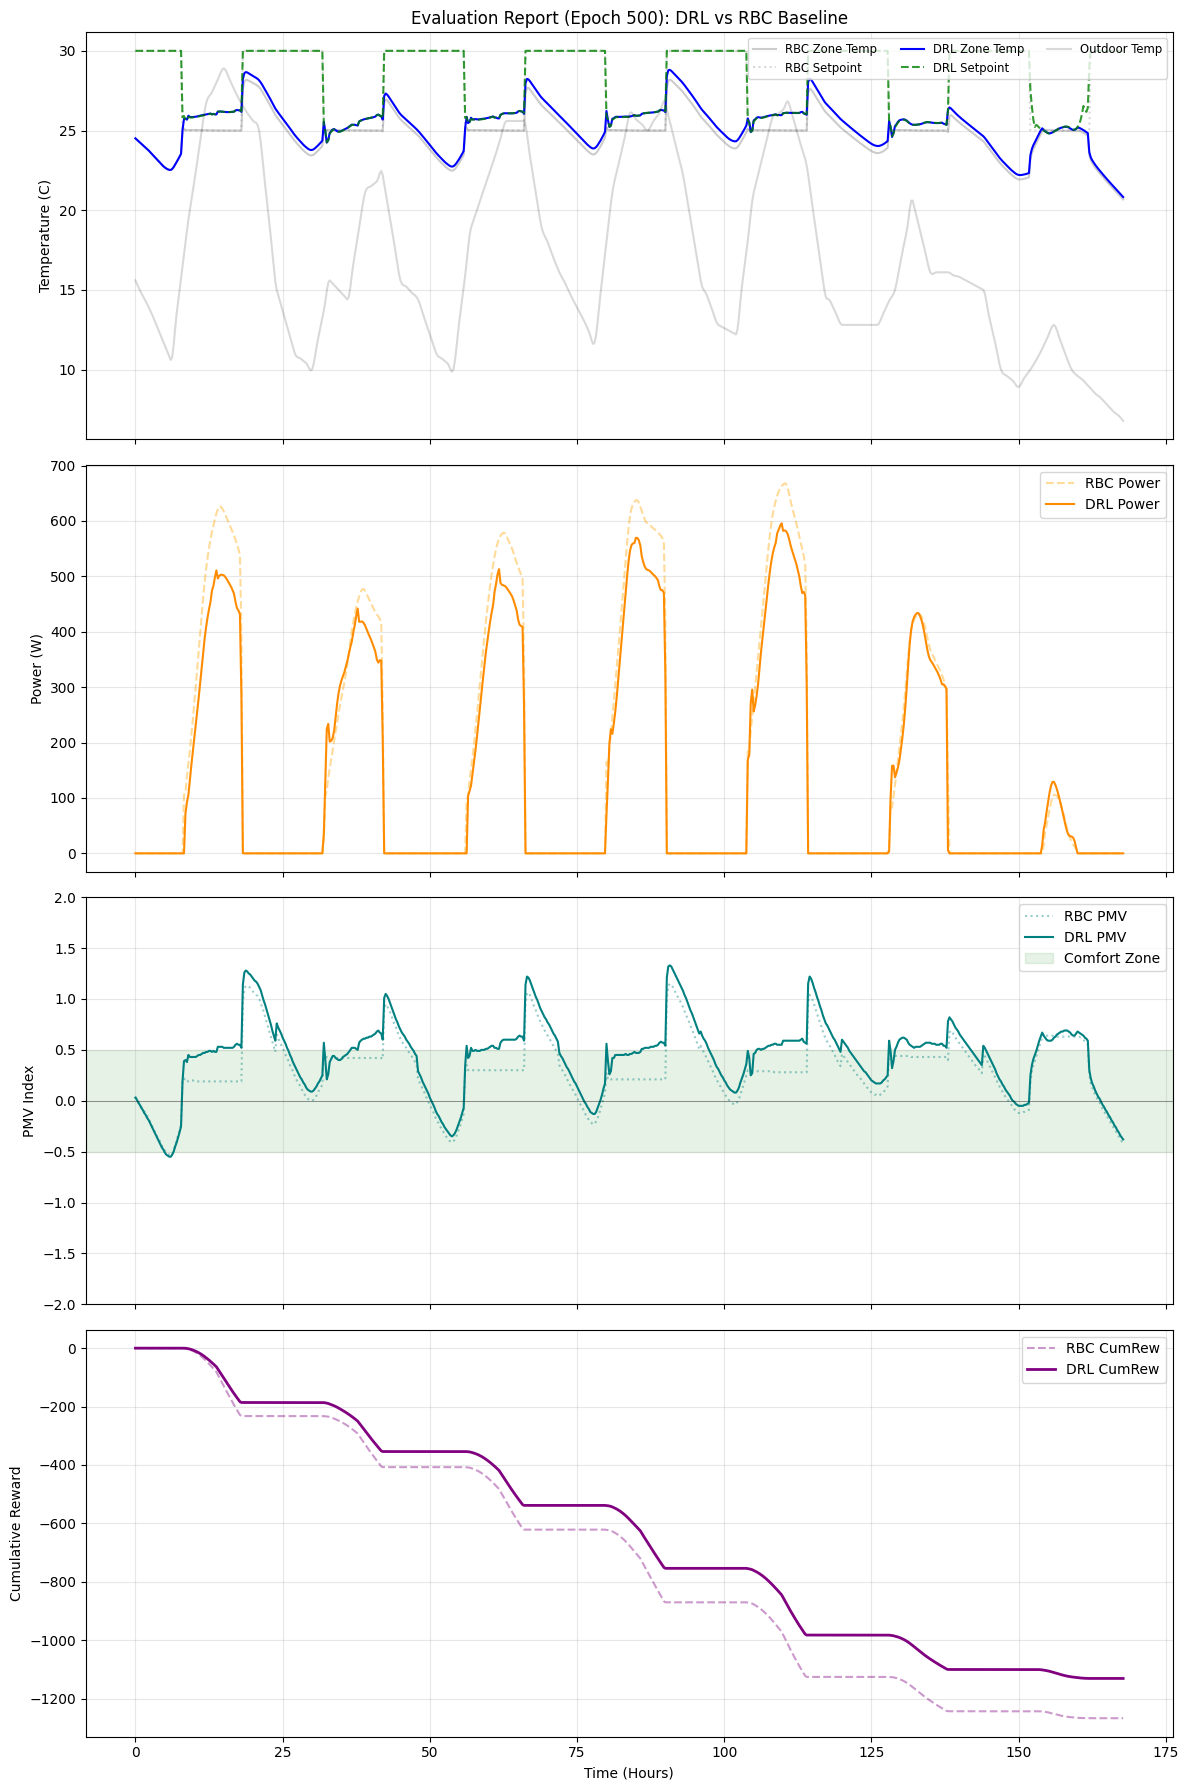

In [38]:
# ==============================================================================
# CELL 3: OPTIMIZED DRL (PPO) TRAINING WITH FULL DIAGNOSTICS & LOCAL FORECAST
# ==============================================================================

import os
import gymnasium as gym
import torch
import requests
import pandas as pd
import numpy as np
import time
import traceback
import json
import gc
import subprocess
import shlex
import sys
import math
import matplotlib.pyplot as plt
from collections import deque
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

# 引入物理计算库
try:
    from pythermalcomfort.models import pmv_ppd_iso
except ImportError:
    pmv_ppd_iso = None

# 1. 定义全局总步数
total_overall_steps = config.PPO_PARAMS['n_steps'] * 4 * config.TOTAL_DRL_EPOCHS

# 2. 修改调度器逻辑，使其基于全局步数计算
def global_linear_schedule(initial_value):
    def func(progress_remaining):
        """
        progress_remaining: 从 1.0 (开始) 逐渐降到 0.0 (结束)
        逻辑：
        - 当 progress = 1.0 时，返回 initial_value * (0.9 * 1.0 + 0.1) = initial_value
        - 当 progress = 0.0 时，返回 initial_value * (0.9 * 0.0 + 0.1) = 0.1 * initial_value
        """
        return initial_value * (0.9 * progress_remaining + 0.1)
    return func
# ==============================================================================
# 1. ForecastProvider: 预取预测数据辅助类 (核心优化)
# ==============================================================================

class ForecastProvider:
    def __init__(self, config):
        self.config = config
        self.data = {}
        # 预取范围：RBC 采集天数 (14天) + 缓冲区 (1天)
        self.start_time = config.START_DAY * 24 * 3600
        self.total_horizon = (config.RBC_COLLECT_DAYS + 1) * 24 * 3600 

    def prefetch_all(self):
        print(f"\n[ForecastProvider] 正在预取全量数据 (Horizon: {self.total_horizon/3600:.1f}h)...")
        try:
            sel_url = f"{self.config.BOPTEST_URL}/testcases/{self.config.CASE_NAME}/select"
            res_sel = requests.post(sel_url, timeout=60).json()
            tid = res_sel['testid']
            
            requests.put(f"{self.config.BOPTEST_URL}/scenario/{tid}", json={'electricity_price': 'dynamic'})
            requests.put(f"{self.config.BOPTEST_URL}/initialize/{tid}", 
                         json={'start_time': self.start_time, 'warmup_period': 0})
            
            f_payload = {
                'point_names': self.config.FORECAST_POINTS,
                'horizon': self.total_horizon,
                'interval': self.config.CONTROL_PERIOD
            }
            res_f = requests.put(f"{self.config.BOPTEST_URL}/forecast/{tid}", json=f_payload, timeout=120).json()
            
            if 'payload' in res_f:
                self.data = {k: np.array(v) for k, v in res_f['payload'].items()}
                print(f"[ForecastProvider] 预取成功。点位: {list(self.data.keys())}, 长度: {len(next(iter(self.data.values())))}")
            
            requests.put(f"{self.config.BOPTEST_URL}/stop/{tid}")
        except Exception as e:
            print(f"[ForecastProvider] 预取失败: {e}")
            raise e

    def get_local_forecast(self, current_time, point_name, horizon_steps=5):
        rel_time = current_time - self.start_time
        idx = int(max(0, rel_time // self.config.CONTROL_PERIOD))
        full_series = self.data.get(point_name)
        if full_series is None: return np.zeros(horizon_steps)
        vals = full_series[idx : idx + horizon_steps]
        if len(vals) < horizon_steps:
            padding = [vals[-1]] * (horizon_steps - len(vals)) if len(vals) > 0 else [0.0] * horizon_steps
            vals = np.concatenate([vals, padding])
        return vals

# ==============================================================================
# 2. 物理与辅助函数
# ==============================================================================

def safe_float(val, default=0.0):
    try:
        if val is None: return default
        f = float(val)
        return f if not (math.isnan(f) or math.isinf(f)) else default
    except: return default

def get_dynamic_clo(daily_mean_tout, params):
    t = safe_float(daily_mean_tout, 20.0)
    if t < params['temp_low']: return params['winter_clo']
    elif t > params['temp_high']: return params['summer_clo']
    else:
        ratio = (t - params['temp_low']) / (params['temp_high'] - params['temp_low'])
        return params['winter_clo'] + ratio * (params['summer_clo'] - params['winter_clo'])

def calculate_pmv_state(t_air_k, phys_config, clo_val):
    if pmv_ppd_iso is None: return 0.0
    t_c = safe_float(t_air_k, 293.15) - 273.15
    try:
        res = pmv_ppd_iso(tdb=t_c, tr=t_c, vr=phys_config['air_velocity'],
                          rh=phys_config['relative_humidity'], met=phys_config['metabolic_rate'], 
                          clo=safe_float(clo_val, 0.5))
        return safe_float(res['pmv'] if isinstance(res, dict) else res.pmv, 0.0)
    except: return 0.0

def _make_request_with_retry(method, url, rank, context_msg, max_retries=5, **kwargs):
    for attempt in range(max_retries):
        try:
            kwargs.setdefault('timeout', 90)
            response = requests.request(method, url, **kwargs)
            if response.status_code == 200:
                return response.json() if response.content else {'status': 'success'}
            # 忽略特定的 stop 错误，不进行不必要的重试
            if response.status_code == 400 and "stop" in url:
                return {'status': 'ignored_error'}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 * (attempt + 1)) # 指数退避
            else:
                print(f"[Rank {rank}] {context_msg} 最终失败: {e}")
    return None

def wait_for_server_ready(config_obj, retries=60, delay=3):
    check_url = f"{config_obj.BOPTEST_URL}/version"
    for i in range(retries):
        try:
            if requests.get(check_url, timeout=10).status_code == 200:
                print(f"[SUCCESS] BOPTEST API 已就绪。")
                return
        except: pass
        time.sleep(delay)

def get_normalization_bounds(config):
    lows, highs = [], []
    for col in config.OBSERVATION_COLUMNS:
        base_key = col.replace('obs_', '')
        for s in ['_past_1', '_past_2', '_past_3', '_past_4', '_current', '_future_1', '_future_2', '_future_3', '_future_4']:
            if s in base_key: base_key = base_key.replace(s, '')
        key = 'zon_reaTRooAir_y' if 'zon_reaTRooAir_y' in base_key else \
              'Occupancy[1]' if 'Occupancy' in base_key else \
              'sin_time' if ('sin' in base_key or 'cos' in base_key) else \
              'action_cool' if 'action_cool' in base_key else \
              'power_norm' if 'power_norm' in base_key else base_key
        val_range = config.OBSERVATIONS_CONFIG.get(key, (0.0, 1.0))
        lows.append(val_range[0]); highs.append(val_range[1])
    return np.array(lows, dtype=np.float32), np.array(highs, dtype=np.float32)

class NormalizedObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.low_b, self.high_b = env.observation_space.low, env.observation_space.high
        self.range_b = self.high_b - self.low_b
        self.range_b[self.range_b == 0] = 1.0 
        self.observation_space = gym.spaces.Box(low=-1.0, high=1.0, shape=self.observation_space.shape, dtype=np.float32)
    def observation(self, obs):
        obs = np.nan_to_num(obs, nan=0.0)
        return np.nan_to_num(2.0 * (obs - self.low_b) / self.range_b - 1.0, nan=0.0)

# ==============================================================================
# 3. DRL 环境类 (集成 ForecastProvider)
# ==============================================================================

class BestestAirResidualEnv(gym.Env):
    def __init__(self, config_obj, forecast_provider, is_validation=False, rank=0):
        super().__init__()
        self.config, self.fp, self.rank = config_obj, forecast_provider, rank
        self.url = self.config.BOPTEST_URL
        self.is_validation = is_validation
        start_day = self.config.START_DAY + 7 if is_validation else self.config.START_DAY
        self.start_time = start_day * 24 * 3600
        self.max_episode_steps = int(7 * 24 * 3600 / self.config.CONTROL_PERIOD)
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        low_b, high_b = get_normalization_bounds(self.config)
        self.observation_space = gym.spaces.Box(low=low_b, high=high_b, dtype=np.float32)
        self.testid = None
        self.history_temp, self.history_action, self.history_power = deque(maxlen=5), deque(maxlen=5), deque(maxlen=5)

    def get_observations(self, y_current):
        try:
            cur_t = safe_float(y_current.get('time', self.start_time))
            raw_obs = {}
            for point in self.config.FORECAST_POINTS:
                vals = self.fp.get_local_forecast(cur_t, point, 5)
                raw_obs[f'obs_{point}_current'] = vals[0]
                for i in range(4): raw_obs[f'obs_{point}_future_{i+1}'] = vals[i+1]
            
            t_day = cur_t % 86400
            raw_obs['obs_sin_time'], raw_obs['obs_cos_time'] = np.sin(2*np.pi*t_day/86400), np.cos(2*np.pi*t_day/86400)
            
            h_temp = list(self.history_temp)
            raw_obs['obs_zon_reaTRooAir_y'] = h_temp[-1] if h_temp else 297.15
            for i in range(1, 5): raw_obs[f'obs_zon_reaTRooAir_y_past_{i}'] = h_temp[-(i+1)] if len(h_temp) > i else h_temp[0]
            
            h_act = list(self.history_action)
            for i in range(1, 5): raw_obs[f'obs_action_cool_past_{i}'] = h_act[-(i+1)] if len(h_act) > i else h_act[0]
            
            h_pow = list(self.history_power)
            for i in range(1, 5): raw_obs[f'obs_power_norm_past_{i}'] = (h_pow[-(i+1)] if len(h_pow) > i else 0.0) / self.config.MAX_SYSTEM_POWER
            
            raw_obs['obs_pp_pmv_y'] = self.current_pmv
            return np.array([raw_obs.get(c, safe_float(y_current.get(c.replace('obs_',''), 0.0))) for c in self.config.OBSERVATION_COLUMNS], dtype=np.float32)
        except: return np.zeros(len(self.config.OBSERVATION_COLUMNS), dtype=np.float32)

    def reset(self, seed=None, options=None):
        # 1. 带有重试机制的 TestID 获取
        if self.testid is None:
            for i in range(5):
                res = _make_request_with_retry('post', f'{self.url}/testcases/{self.config.CASE_NAME}/select', self.rank, "select")
                if res and 'testid' in res:
                    self.testid = res['testid']
                    break
                time.sleep(5)
            
            if self.testid is None:
                raise RuntimeError(f"[Rank {self.rank}] 无法连接 BOPTEST，请检查 Docker。")

            _make_request_with_retry('put', f'{self.url}/step/{self.testid}', self.rank, "set_step", json={'step': self.config.CONTROL_PERIOD})
            _make_request_with_retry('put', f'{self.url}/scenario/{self.testid}', self.rank, "set_scen", json={'electricity_price': 'dynamic'})

        # 2. 带有保护的初始化
        res_init = _make_request_with_retry('put', f'{self.url}/initialize/{self.testid}', self.rank, "init", 
                                            json={'start_time': self.start_time, 'warmup_period': 7*24*3600})
        
        if not res_init or 'payload' not in res_init:
            self.testid = None # 重置以便下次彻底重启
            raise RuntimeError(f"[Rank {self.rank}] 初始化失败，响应为空。")

        y = res_init['payload']
        self.current_step, self.current_pmv, self.current_clo = 0, 0.0, 0.5
        t_init = safe_float(y.get('zon_reaTRooAir_y'), 297.15)
        self.history_temp = deque([t_init]*5, maxlen=5)
        self.history_action = deque([273.15 + 24.0]*5, maxlen=5)
        self.history_power = deque([0.0]*5, maxlen=5)
        return self.get_observations(y), {}

    def step(self, action_norm):
        cur_t = self.start_time + self.current_step * self.config.CONTROL_PERIOD
        occ = self.fp.get_local_forecast(cur_t, 'Occupancy[1]', 1)[0]
        rbc_base = 25.0
        set_cool_k = np.clip(rbc_base + float(action_norm[0])*self.config.RESIDUAL_ACTION_SCALE + 273.15, 288.15, 303.15)
        
        res = _make_request_with_retry('post', f'{self.url}/advance/{self.testid}', self.rank, "adv", 
                                      json={'con_oveTSetCoo_u': set_cool_k, 'con_oveTSetCoo_activate': 1,
                                            'con_oveTSetHea_u': self.config.FIXED_HEATING_SETPOINT+273.15, 'con_oveTSetHea_activate': 1})
        y_next = res['payload']
        t_zone = safe_float(y_next.get('zon_reaTRooAir_y'))
        p_total = safe_float(y_next.get('fcu_reaPCoo_y', 0)) + safe_float(y_next.get('fcu_reaPFan_y', 0))
        
        if self.current_step % 96 == 0: # 每天更新一次 CLO
            tout = np.mean(self.fp.get_local_forecast(cur_t, 'TDryBul', 96)) - 273.15
            self.current_clo = get_dynamic_clo(tout, self.config.PHYSICAL_CONFIG['clo_dynamic_params'])
        
        self.current_pmv = calculate_pmv_state(t_zone, self.config.PHYSICAL_CONFIG, self.current_clo)
        price = self.fp.get_local_forecast(cur_t, 'PriceElectricPowerDynamic', 1)[0]
        cost = (p_total * self.config.CONTROL_PERIOD / 3600000) * price
        
        w, n_z = self.config.REWARD_WEIGHTS, self.config.N_ZONES
        en_r = (cost / n_z) * w['scaler_energy']
        cm_r = (max(0, abs(self.current_pmv)-0.5)**2 * w['scaler_comfort']) if occ > 0 else 0
        sm_r = (abs(set_cool_k - self.history_action[-1]) / n_z) * w['scaler_smooth']
        reward = -1.0 * (w['w_energy']*en_r + w['w_comfort']*cm_r + w['w_smooth']*sm_r)
        
        self.history_temp.append(t_zone); self.history_action.append(set_cool_k); self.history_power.append(p_total)
        self.current_step += 1
        info = {'phys_temp': t_zone-273.15, 'phys_cost': cost, 'phys_pmv_abs': abs(self.current_pmv),
                'phys_action_diff': abs(set_cool_k-self.history_action[-2]), 'setpoint': set_cool_k-273.15,
                'rew_energy': w['w_energy']*en_r, 'rew_comfort': w['w_comfort']*cm_r, 'rew_smooth': w['w_smooth']*sm_r}
        return self.get_observations(y_next), reward, False, self.current_step >= self.max_episode_steps, info

# ==============================================================================
# 4. 回调函数: 还原诊断打印、CSV日志、最佳模型保存
# ==============================================================================

class SaveOnBestTrainingRewardCallback(BaseCallback):
    def __init__(self, config_obj, verbose=1):
        super().__init__(verbose)
        self.config = config_obj
        self.save_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'best_model_ppo')
        self.log_path = os.path.join(self.config.LOG_DIRS['drl_models'], 'ppo_training_log.csv')
        self.best_mean_reward = -np.inf
        
        # --- 核心修改：防止覆盖，载入现有日志 ---
        if os.path.exists(self.log_path):
            try:
                # 读取现有记录并转换为列表
                existing_df = pd.read_csv(self.log_path)
                self.training_log = existing_df.to_dict('records')
                # 更新 epoch_count 为现有记录的数量
                self.epoch_count = len(self.training_log)
                print(f"[Log] 发现现有日志，将从 Epoch {self.epoch_count + 1} 开始接续记录。")
                
                # 如果模型已经有过训练，尝试更新 best_mean_reward 防止重复保存
                if not existing_df.empty:
                    self.best_mean_reward = existing_df['MeanReward'].max()
            except Exception as e:
                print(f"[Log] 读取旧日志失败 ({e})，将创建新日志。")
                self.training_log = []
                self.epoch_count = 0
        else:
            self.training_log = []
            self.epoch_count = 0
            
        self.epoch_infos = []
        self.start_time = time.time()

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if 'rew_energy' in info: self.epoch_infos.append(info)
        return True

    def _on_rollout_end(self) -> bool:
        # PPO 每次 rollout 结束（对应 4 个并行环境完成了各自的 n_steps）作为一个 Epoch 计数
        self.epoch_count += 1
        ep_rewards = [ep_info['r'] for ep_info in self.model.ep_info_buffer]
        self.model.ep_info_buffer.clear()
        mean_reward = np.mean(ep_rewards) if ep_rewards else -9999
        duration = time.time() - self.start_time

        # 打印分析表格
        if self.epoch_infos:
            avg_cost = np.mean([x['phys_cost'] for x in self.epoch_infos])
            avg_pmv = np.mean([x['phys_pmv_abs'] for x in self.epoch_infos])
            avg_act = np.mean([x['phys_action_diff'] for x in self.epoch_infos])
            r_en = np.mean([x['rew_energy'] for x in self.epoch_infos])
            r_cm = np.mean([x['rew_comfort'] for x in self.epoch_infos])
            r_sm = np.mean([x['rew_smooth'] for x in self.epoch_infos])
            total_penalty = max(1e-6, r_en + r_cm + r_sm)

            print(f"\n[Epoch {self.epoch_count} Analysis]")
            print("-" * 75)
            print(f"| Component      | Raw Avg    | Weighted Avg (Contrib) |")
            print("-" * 75)
            print(f"| Energy         | $ {avg_cost:.4f}   | - {r_en:.3f}  ({r_en/total_penalty*100:.1f}%) |")
            print(f"| Comfort        | {avg_pmv:.3f} (PMV) | - {r_cm:.3f}  ({r_cm/total_penalty*100:.1f}%) |")
            print(f"| Smoothness     | {avg_act:.3f} (K)   | - {r_sm:.3f}  ({r_sm/total_penalty*100:.1f}%) |")
            print("-" * 75)
            print(f"| TOTAL REWARD   |            | {mean_reward:.3f} |")
            print("-" * 75)
            self.epoch_infos = []

        # 追加新记录
        self.training_log.append({
            'Epoch': self.epoch_count, 
            'MeanReward': mean_reward, 
            'Time': duration
        })
        
        # 保存完整日志（包含之前的记录）
        pd.DataFrame(self.training_log).to_csv(self.log_path, index=False)
        
        # 存下表现最好的模型
        if mean_reward > self.best_mean_reward:
            self.model.save(self.save_path)
            self.best_mean_reward = mean_reward
            print(f"[*] 发现更佳模型，已保存至: {self.save_path}")

        self.start_time = time.time()
        return True

# ==============================================================================
# 5. 评估与主循环
# ==============================================================================

class StopAtStepCallback(BaseCallback):
    """
    一个简单的回调，当全局步数达到指定的 stop_step 时停止训练。
    """
    def __init__(self, stop_step, verbose=0):
        super().__init__(verbose)
        self.stop_step = stop_step

    def _on_step(self) -> bool:
        # 如果当前全局步数达到了目标，返回 False 停止 learn()
        return self.num_timesteps < self.stop_step

def run_evaluation(model, epoch_idx, config_obj, fp, restart=False):
    print(f"\n[Eval] 正在运行第 {epoch_idx} Epoch 的原位验证...")
    
    # 只有在需要时才重启（例如最后一次），平时训练中途不重启
    if restart:
        restart_boptest(config_obj)
        time.sleep(15)

    # 创建一个独立的验证环境实例（不影响 vec_env）
    # rank=-1 确保它去申请一个新的 testid，而不占用训练用的 testid
    raw_env = BestestAirResidualEnv(config_obj, fp, is_validation=True, rank=-1)
    env = NormalizedObservationWrapper(raw_env)
    
    # 加载 RBC 用于对比
    rbc_path = os.path.join(config_obj.LOG_DIRS['rbc_data'], 'rbc_validation_bestest_air.csv')
    df_rbc = pd.read_csv(rbc_path)
    
    obs, _ = env.reset() # 这里会调用 initialize，把模拟时钟拨回验证周
    done, logs = False, []
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        done = term or trunc
        info['reward'] = reward 
        info['power_total'] = raw_env.history_power[-1]
        info['phys_pmv_raw'] = raw_env.current_pmv 
        info['temp_out'] = df_rbc['temp_out'].iloc[len(logs)] if len(logs) < len(df_rbc) else 0
        logs.append(info)
    
    df_drl = pd.DataFrame(logs)
    # 对齐 RBC 数据长度（以 DRL 步数为准）
    df_rbc_sync = df_rbc.iloc[:len(df_drl)].copy()
    
    time_h = np.arange(len(df_drl)) * config_obj.CONTROL_PERIOD / 3600
    
    # 开启绘图 - 采用 4 面板布局对齐 RBC 风格
    fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)
    
    # --- Panel 1: 温度响应与设定值对比 ---
    axes[0].plot(time_h, df_rbc_sync['temp_zone'], label='RBC Zone Temp', color='gray', linestyle='-', alpha=0.4)
    axes[0].plot(time_h, df_rbc_sync['setpoint_cool'], label='RBC Setpoint', color='gray', linestyle=':', alpha=0.3)
    axes[0].plot(time_h, df_drl['phys_temp'], label='DRL Zone Temp', color='blue', linewidth=1.5)
    axes[0].plot(time_h, df_drl['setpoint'], label='DRL Setpoint', color='green', linestyle='--', alpha=0.8)
    axes[0].plot(time_h, df_rbc_sync['temp_out'], label='Outdoor Temp', color='black', alpha=0.15)
    axes[0].set_ylabel('Temperature (C)')
    axes[0].set_title(f'Evaluation Report (Epoch {epoch_idx}): DRL vs RBC Baseline')
    axes[0].legend(loc='upper right', ncol=3, fontsize='small')
    axes[0].grid(True, alpha=0.3)
    
    # --- Panel 2: 功率消耗对比 ---
    axes[1].plot(time_h, df_rbc_sync['power_total'], label='RBC Power', color='orange', linestyle='--', alpha=0.4)
    axes[1].plot(time_h, df_drl['power_total'], label='DRL Power', color='darkorange', linewidth=1.5)
    axes[1].set_ylabel('Power (W)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # --- Panel 3: PMV 舒适度对比 ---
    axes[2].plot(time_h, df_rbc_sync['pmv'], label='RBC PMV', color='teal', linestyle=':', alpha=0.4)
    axes[2].plot(time_h, df_drl['phys_pmv_raw'], label='DRL PMV', color='teal', linewidth=1.5)
    axes[2].axhspan(-0.5, 0.5, color='green', alpha=0.1, label='Comfort Zone') # 舒适区阴影
    axes[2].axhline(0, color='black', linewidth=0.5, alpha=0.5)
    axes[2].set_ylabel('PMV Index')
    axes[2].set_ylim(-2, 2)
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    
    # --- Panel 4: 累计奖励对比 ---
    axes[3].plot(time_h, df_rbc_sync['reward'].cumsum(), label='RBC CumRew', color='purple', linestyle='--', alpha=0.4)
    axes[3].plot(time_h, df_drl['reward'].cumsum(), label='DRL CumRew', color='purple', linewidth=2)
    axes[3].set_ylabel('Cumulative Reward')
    axes[3].set_xlabel('Time (Hours)')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 保存图像
    plot_filename = os.path.join(config_obj.LOG_DIRS['results'], f"eval_report_epoch_{epoch_idx}.png")
    plt.savefig(plot_filename)
    print(f"[Storage] 评估对比图像已保存至: {plot_filename}")
    
    #plt.show() 
    
    # 保存 CSV 数据
    data_filename = os.path.join(config_obj.LOG_DIRS['results'], f"eval_data_epoch_{epoch_idx}.csv")
    df_drl.to_csv(data_filename, index=False)
    print(f"[Storage] 评估原始数据已保存至: {data_filename}")

    # 打印简要对比结果
    drl_cost = df_drl['phys_cost'].sum()
    rbc_cost = df_rbc_sync['cost'].sum()
    savings = (1 - drl_cost / rbc_cost) * 100
    print(f"\n>>> 性能简报 (Epoch {epoch_idx}):")
    print(f"DRL 总成本: ${drl_cost:.2f} | RBC 总成本: ${rbc_cost:.2f}")
    print(f"当前节能率 (Energy Savings): {savings:.2f}%")

    # 清理
    if raw_env.testid: _make_request_with_retry('put', f"{config_obj.BOPTEST_URL}/stop/{raw_env.testid}", -1, "eval_stop")

def restart_boptest(config_obj):
    cwd = "C:\\project1-boptest-master"
    subprocess.run(shlex.split("docker compose down -v"), cwd=cwd, stderr=subprocess.DEVNULL)
    subprocess.run(shlex.split("docker compose up web worker provision --scale worker=5 -d"), cwd=cwd, check=True)
    wait_for_server_ready(config_obj)
    # 关键：给后端留出初始化时间
    print("[System] API 基础响应正常，等待后端服务稳定 (10s)...")
    time.sleep(10)

def main_training_loop():
    # 1. 准备工作
    fp = ForecastProvider(config)
    fp.prefetch_all()
    restart_boptest(config)
    
    # 2. 创建并行训练环境
    vec_env = SubprocVecEnv([
        lambda i=i: Monitor(NormalizedObservationWrapper(BestestAirResidualEnv(config, fp, rank=i))) 
        for i in range(4)
    ])
    
    # 3. 规划总步数
    steps_per_epoch = config.PPO_PARAMS['n_steps'] * 4
    total_overall_steps = steps_per_epoch * config.TOTAL_DRL_EPOCHS
    
    # 4. 模型实例化
    model = PPO('MlpPolicy', vec_env, verbose=1, seed=config.SEED, 
                **{**config.PPO_PARAMS, 'learning_rate': global_linear_schedule(config.PPO_PARAMS['learning_rate'])})
    
    diag_callback = SaveOnBestTrainingRewardCallback(config)
    
    print(f"\n>>> 开始连续训练: 共 {config.TOTAL_DRL_EPOCHS} Epochs, 总计 {total_overall_steps} 步。")
    
    # 5. 执行一次性完整训练
    try:
        model.learn(
            total_timesteps=total_overall_steps,
            callback=diag_callback,
            reset_num_timesteps=True
        )
    except Exception as e:
        print(f"[Fatal] 训练异常中断: {e}")
        traceback.print_exc()
    finally:
        # 先关闭训练环境释放资源
        vec_env.close()
    
    # --- 关键修正位置：在 learn 结束后正确执行评估 ---
    best_zip = diag_callback.save_path + ".zip"
    if os.path.exists(best_zip):
        print(f"[*] 训练完成。正在载入历史最佳模型进行最终绘图评估...")
        # 修正 1: 必须先从硬盘加载 PPO 模型对象
        final_best_model = PPO.load(best_zip)
        
        # 修正 2: 严格按照定义传递参数 (model, epoch_idx, config_obj, fp)
        # 定义：def run_evaluation(model, epoch_idx, config_obj, fp, restart=False):
        run_evaluation(
            model=final_best_model, 
            epoch_idx=config.TOTAL_DRL_EPOCHS, 
            config_obj=config, 
            fp=fp, 
            restart=False
        )
    else:
        print("[Warning] 未找到保存的最佳模型，跳过最终验证。")

if __name__ == '__main__':
    main_training_loop()